<a href="https://colab.research.google.com/github/utamiu1807/Final-Project-A-Spatiotemporal-Deep-Learning-Extension/blob/main/finalCompVision_sentimentanalysis_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chicago Crash Risk — Complete 4-Week Project Notebook

**Group 10 · MSPPM-DA '27**

This is one self-contained notebook. Every utility function, configuration value, and pipeline step is **inlined directly into the notebook** — there are no external `.py` files to import or `runpy` calls. You can run this on any machine that has the data files and the Python dependencies.

## What it produces

By the end of Section 4 you will have:

- A spatiotemporal forecasting tensor built from your 328k crash records
- Three calibrated baseline models (historical avg, Negative Binomial GLM, LightGBM-Poisson)
- Calibration plots, PAI curves, comparison table
- Equity audit across 77 Chicago community areas
- A CDOT-ready priority list with intervention recommendations
- An interactive Folium map for stakeholders

## Required input files

You need two CSVs from your midterm pipeline:
- `data/cleaned/train_model.csv`
- `data/cleaned/test_model.csv`

Place them in those exact paths relative to where this notebook lives, or update the paths in Section 0.

## How to run

1. Open this notebook in VS Code with your project's `.venv` selected as the kernel
2. Run cells top to bottom with `Shift+Enter`
3. Section 0 installs dependencies (5-10 min first time)
4. Sections 1-4 run end-to-end in about 6-8 minutes

No terminal commands needed.

---

# Section 0 — Setup

## 0.1 — Set working directory

Find the project root regardless of whether the notebook lives in `notebooks/` or at the project root.

In [184]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import lightgbm as lgb
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import geopandas as gpd
import requests
import folium
from datetime import datetime, timedelta
from scipy.stats import pearsonr, spearmanr
from dataclasses import dataclass
import time
import cv2
from ultralytics import YOLO

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))
print(f"Working directory: {os.getcwd()}")

Working directory: /content


## 0.2 — Install dependencies

Single `%pip install` cell. First run: ~5-10 minutes (LightGBM and statsmodels are the slowest). Subsequent runs are near-instant.

In [185]:
%pip install -q numpy pandas scipy scikit-learn matplotlib seaborn \
                lightgbm statsmodels folium tabulate
print("Done.")

Done.


## 0.3 — Verify input files exist

In [186]:
train_url = "https://drive.google.com/uc?id=1ZyEDxGfqh2wQj3JaNht_SnIPqK5MwJb7"
test_url = "https://drive.google.com/uc?id=1BKm-7-cBSiZ2NRzm0Ykt45R8RlDo_FAJ"
# Corrected direct download link for Speed Camera Locations
Speed_Camera_Locations_url = "https://drive.google.com/uc?export=download&id=1qhu7cRPetpn6DuiCdUPiDrkiq7MKCEhs"

raw_train = pd.read_csv(train_url)
raw_test = pd.read_csv(test_url)
speed_camera_loc = pd.read_csv(Speed_Camera_Locations_url)
from pathlib import Path

Path("sample_data").mkdir(parents=True, exist_ok=True)

speed_camera_loc.to_csv(
    "sample_data/Speed_Camera_Locations.csv",
    index=False
)

print("Saved speed camera CSV locally.")

print(raw_train.shape)
print(raw_test.shape)
print(speed_camera_loc)

Saved speed camera CSV locally.
(246221, 96)
(82274, 96)
      ID LOCATION ID               ADDRESS FIRST APPROACH SECOND APPROACH  \
0    195      CHI015        3450 W 71st St             WB              EB   
1    232      CHI039  6247 W Fullerton Ave             EB             NaN   
2    233      CHI040  6250 W Fullerton Ave             WB             NaN   
3    227      CHI041  5509 W Fullerton Ave             EB             NaN   
4    226      CHI042  5446 W Fullerton Ave             WB             NaN   
..   ...         ...                   ...            ...             ...   
207   86      CHI247        4298 w 59th St             WB              EB   
208   97      CHI256   4424 W Diversey Ave             WB              EB   
209   55      CHI212   8740 S Vincennes St             NB              SB   
210   52      CHI210       2310 E 103rd St             EB              WB   
211   92      CHI251       451 E Grand Ave             WB             NaN   

    GO-LIVE DATE  

## 0.4 — Configuration

All settings for the whole project live in this one dictionary. Change values here, not later in the notebook.

In [187]:
# Master configuration — every cell below reads from this CFG dict
CFG = {
    # Inputs
    "raw_train": "raw_train",
    "raw_test":  "raw_test",

    # Spatial grid (must match midterm)
    "grid": {
        "cell_size_deg": 0.005,    # ~500m
        "lat_min": 41.64,
        "lat_max": 42.03,
        "lon_min": -87.95,
        "lon_max": -87.52,
    },

    # Temporal binning
    "time": {
        "bin_hours": 6,            # 4 windows per day
        "train_start": "2023-01-01",
        "train_end":   "2025-04-05",
        "test_start":  "2025-04-05",
        "test_end":    "2025-12-31",
    },

    # Target
    "target": "is_severe",

    # Channels
    "history_channels": ["severe_count", "total_crash_count",
                         "night_indicator", "weekend_indicator"],
    "static_channels": ["mean_speed_limit", "intersection_density", "aadt_log"],

    # Output paths
    "tensor_train": "data/tensors/tensor_train.npz",
    "tensor_test":  "data/tensors/tensor_test.npz",
    "cell_meta":    "data/tensors/cell_meta.csv",
    "outputs":      "outputs/",

    # Evaluation
    "pai_top_k": [50, 100, 200, 500],
    "calibration_bins": 10,
}

# Make sure output folders exist
for d in ["data/tensors", "outputs", "outputs/clip_overlays"]:
    Path(d).mkdir(parents=True, exist_ok=True)

print("Configuration loaded.")
print(f"  Grid: {CFG['grid']['cell_size_deg']}° × {CFG['grid']['cell_size_deg']}°")
print(f"  Time bins: {CFG['time']['bin_hours']}h")
print(f"  Train window: {CFG['time']['train_start']} → {CFG['time']['train_end']}")
print(f"  Test window:  {CFG['time']['test_start']} → {CFG['time']['test_end']}")

Configuration loaded.
  Grid: 0.005° × 0.005°
  Time bins: 6h
  Train window: 2023-01-01 → 2025-04-05
  Test window:  2025-04-05 → 2025-12-31


## 0.5 — Utility functions: geometry

Grid-cell indexing helpers. Used by Weeks 1, 2, 4 to map (lat, lon) ↔ (h, w) cell coordinates.

In [188]:
@dataclass
class GridSpec:
    cell_size_deg: float
    lat_min: float
    lat_max: float
    lon_min: float
    lon_max: float

    @property
    def H(self):
        return int(np.ceil((self.lat_max - self.lat_min) / self.cell_size_deg))

    @property
    def W(self):
        return int(np.ceil((self.lon_max - self.lon_min) / self.cell_size_deg))

    def latlon_to_hw(self, lat, lon):
        """Vectorised: returns (h_idx, w_idx). Out-of-bounds points get -1."""
        lat = np.asarray(lat, dtype=np.float64)
        lon = np.asarray(lon, dtype=np.float64)
        in_bounds = ((lat >= self.lat_min) & (lat < self.lat_max) &
                     (lon >= self.lon_min) & (lon < self.lon_max))
        h = np.floor((lat - self.lat_min) / self.cell_size_deg).astype(np.int64)
        w = np.floor((lon - self.lon_min) / self.cell_size_deg).astype(np.int64)
        h = np.where(in_bounds, h, -1)
        w = np.where(in_bounds, w, -1)
        return h, w

    def hw_to_latlon_center(self, h, w):
        lat = self.lat_min + (np.asarray(h) + 0.5) * self.cell_size_deg
        lon = self.lon_min + (np.asarray(w) + 0.5) * self.cell_size_deg
        return lat, lon

    def populated_cells(self, lat, lon):
        h, w = self.latlon_to_hw(lat, lon)
        mask = (h >= 0) & (w >= 0)
        df = pd.DataFrame({"h": h[mask], "w": w[mask]})
        agg = df.groupby(["h", "w"]).size().reset_index(name="n_obs")
        agg["lat"], agg["lon"] = self.hw_to_latlon_center(agg["h"], agg["w"])
        return agg


def time_bin_index(timestamps, t_start, bin_hours):
    """Map timestamps to integer bin index (0-based)."""
    ts = pd.to_datetime(timestamps)
    t0 = pd.Timestamp(t_start)
    delta = (ts - t0).dt.total_seconds() / 3600.0
    return np.floor(delta / bin_hours).astype(np.int64).values


# Build the grid we'll use everywhere
GRID = GridSpec(
    cell_size_deg=CFG["grid"]["cell_size_deg"],
    lat_min=CFG["grid"]["lat_min"], lat_max=CFG["grid"]["lat_max"],
    lon_min=CFG["grid"]["lon_min"], lon_max=CFG["grid"]["lon_max"],
)
print(f"Grid: H={GRID.H}, W={GRID.W} ({GRID.H * GRID.W:,} total cells)")

Grid: H=79, W=87 (6,873 total cells)


## 0.6 — Utility functions: evaluation metrics

Poisson deviance, PAI, top-k hit rate, calibration, severe capture. Used by every model evaluation.

In [189]:
def poisson_deviance(y_true, y_pred, eps=1e-9):
    """Mean Poisson deviance: 2 * mean(y * log(y/mu) - (y - mu)). Lower is better."""
    y_true = np.asarray(y_true, dtype=np.float64).ravel()
    y_pred = np.asarray(y_pred, dtype=np.float64).ravel()
    y_pred = np.clip(y_pred, eps, None)
    safe_true = np.where(y_true > 0, y_true, 1.0)
    log_ratio = np.log(safe_true / y_pred)
    term1 = np.where(y_true > 0, y_true * log_ratio, 0.0)
    term2 = y_true - y_pred
    return float(np.mean(2.0 * (term1 - term2)))


def predictive_accuracy_index(y_true, y_pred, top_k):
    """PAI = (n/N) / (a/A). Higher = more concentrated than random."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    A = len(y_true); N = float(y_true.sum())
    if N == 0: return float("nan")
    order = np.argsort(-y_pred)
    n = float(y_true[order[:top_k]].sum())
    return (n / N) / (top_k / A)


def top_k_hit_rate(y_true, y_pred, k):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    true_top = set(np.argsort(-y_true)[:k].tolist())
    pred_top = set(np.argsort(-y_pred)[:k].tolist())
    return len(true_top & pred_top) / k


def severe_capture_rate(y_true, y_pred, k):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    total = float(y_true.sum())
    if total == 0: return float("nan")
    return float(y_true[np.argsort(-y_pred)[:k]].sum()) / total


def expected_calibration_error(y_true, y_pred, n_bins=10):
    y_true = np.asarray(y_true, dtype=np.float64).ravel()
    y_pred = np.asarray(y_pred, dtype=np.float64).ravel()
    quantiles = np.quantile(y_pred, np.linspace(0, 1, n_bins + 1))
    quantiles[0] = -np.inf; quantiles[-1] = np.inf
    ece = 0.0
    n = len(y_true)
    for i in range(n_bins):
        mask = (y_pred > quantiles[i]) & (y_pred <= quantiles[i + 1])
        if mask.sum() == 0: continue
        ece += (mask.sum() / n) * abs(y_pred[mask].mean() - y_true[mask].mean())
    return float(ece)


def calibration_bins(y_true, y_pred, n_bins=10):
    y_true = np.asarray(y_true, dtype=np.float64).ravel()
    y_pred = np.asarray(y_pred, dtype=np.float64).ravel()
    quantiles = np.quantile(y_pred, np.linspace(0, 1, n_bins + 1))
    quantiles[0] = -np.inf; quantiles[-1] = np.inf
    rows = []
    for i in range(n_bins):
        mask = (y_pred > quantiles[i]) & (y_pred <= quantiles[i + 1])
        if mask.sum() == 0: continue
        rows.append({"bin": i,
                     "mean_pred": float(y_pred[mask].mean()),
                     "mean_obs": float(y_true[mask].mean()),
                     "count": int(mask.sum())})
    return rows


def full_report(y_true, y_pred, ks=(50, 100, 200, 500), n_bins=10):
    """One-call evaluation; returns flat dict."""
    out = {
        "poisson_deviance": poisson_deviance(y_true, y_pred),
        "ece": expected_calibration_error(y_true, y_pred, n_bins),
        "total_true": float(np.asarray(y_true).sum()),
        "total_pred": float(np.asarray(y_pred).sum()),
    }
    for k in ks:
        out[f"pai@{k}"]     = predictive_accuracy_index(y_true, y_pred, k)
        out[f"hitrate@{k}"] = top_k_hit_rate(y_true, y_pred, k)
        out[f"capture@{k}"] = severe_capture_rate(y_true, y_pred, k)
    return out


print("Metric functions ready: poisson_deviance, predictive_accuracy_index,")
print("top_k_hit_rate, severe_capture_rate, expected_calibration_error,")
print("calibration_bins, full_report")

Metric functions ready: poisson_deviance, predictive_accuracy_index,
top_k_hit_rate, severe_capture_rate, expected_calibration_error,
calibration_bins, full_report


---

# Section 1 — Week 1: Build the spatiotemporal tensor

Goal: convert 328k crash records into a 4-D tensor `(T, H, W, C)` keyed by 6-hour bins and 500m grid cells.

Sanity check at the end: train tensor should have **4,056** severe crashes (matches midterm exactly).

## 1.1 — Helper: load and clean midterm CSV

In [190]:
def load_midterm_csv(path, limit=None):
    """Load the midterm cleaned CSV with type coercion and required-column check."""
    df = pd.read_csv(path, nrows=limit, low_memory=False)
    required = ["CRASH_DATE", "LATITUDE", "LONGITUDE", "is_severe"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing required columns: {missing}")
    df["CRASH_DATE"] = pd.to_datetime(df["CRASH_DATE"], errors="coerce")
    df = df.dropna(subset=["CRASH_DATE", "LATITUDE", "LONGITUDE"])
    df["LATITUDE"]  = df["LATITUDE"].astype(float)
    df["LONGITUDE"] = df["LONGITUDE"].astype(float)
    df["is_severe"] = df["is_severe"].astype(int)
    return df

print("load_midterm_csv() ready.")

load_midterm_csv() ready.


## 1.2 — Build a tensor from a DataFrame

In [191]:
def build_tensor(df, grid, t_start, t_end, bin_hours, history_channels):
    """Bin crashes into (T, H, W) tensors with feature channels."""
    H, W = grid.H, grid.W

    h_idx, w_idx = grid.latlon_to_hw(df["LATITUDE"].values, df["LONGITUDE"].values)
    t_idx = time_bin_index(df["CRASH_DATE"], t_start, bin_hours)

    total_bins = int(np.ceil(
        (pd.Timestamp(t_end) - pd.Timestamp(t_start)).total_seconds() / 3600.0 / bin_hours
    ))

    valid = (h_idx >= 0) & (w_idx >= 0) & (t_idx >= 0) & (t_idx < total_bins)
    h_idx, w_idx, t_idx = h_idx[valid], w_idx[valid], t_idx[valid]
    severe = df["is_severe"].values[valid]
    n_dropped = (~valid).sum()
    if n_dropped > 0:
        print(f"  dropped {n_dropped:,} crashes outside grid/time window")

    T = total_bins
    severe_count = np.zeros((T, H, W), dtype=np.float32)
    total_count = np.zeros((T, H, W), dtype=np.float32)
    np.add.at(severe_count, (t_idx, h_idx, w_idx), severe.astype(np.float32))
    np.add.at(total_count,  (t_idx, h_idx, w_idx), 1.0)

    bin_starts = pd.date_range(t_start, periods=T, freq=f"{bin_hours}h")
    night_mask = ((bin_starts.hour < 6) | (bin_starts.hour >= 18)).astype(np.float32)
    weekend_mask = (bin_starts.dayofweek >= 5).astype(np.float32)
    night_chan = np.broadcast_to(night_mask[:, None, None], (T, H, W)).astype(np.float32)
    weekend_chan = np.broadcast_to(weekend_mask[:, None, None], (T, H, W)).astype(np.float32)

    channel_map = {
        "severe_count": severe_count, "total_crash_count": total_count,
        "night_indicator": night_chan, "weekend_indicator": weekend_chan,
    }
    available = [c for c in history_channels if c in channel_map]
    X_history = np.stack([channel_map[c] for c in available], axis=-1)
    y = severe_count.copy()

    return {
        "X_history": X_history, "y": y,
        "time_index": np.array([str(d) for d in bin_starts]),
        "channel_names": available,
    }


def build_static_features(df, grid, static_channels):
    """Static features broadcast across all time steps."""
    H, W = grid.H, grid.W
    h_idx, w_idx = grid.latlon_to_hw(df["LATITUDE"].values, df["LONGITUDE"].values)
    valid = (h_idx >= 0) & (w_idx >= 0)
    h_idx, w_idx = h_idx[valid], w_idx[valid]
    layers = {}

    if "mean_speed_limit" in static_channels and "POSTED_SPEED_LIMIT" in df.columns:
        speeds = df["POSTED_SPEED_LIMIT"].values[valid].astype(np.float32)
        sum_s = np.zeros((H, W), dtype=np.float32)
        cnt = np.zeros((H, W), dtype=np.float32)
        np.add.at(sum_s, (h_idx, w_idx), speeds)
        np.add.at(cnt, (h_idx, w_idx), 1.0)
        with np.errstate(invalid="ignore", divide="ignore"):
            layers["mean_speed_limit"] = np.where(cnt > 0, sum_s / cnt, 0.0).astype(np.float32)

    if "intersection_density" in static_channels and "is_intersection" in df.columns:
        is_int = df["is_intersection"].values[valid].astype(np.float32)
        sum_i = np.zeros((H, W), dtype=np.float32)
        cnt = np.zeros((H, W), dtype=np.float32)
        np.add.at(sum_i, (h_idx, w_idx), is_int)
        np.add.at(cnt, (h_idx, w_idx), 1.0)
        with np.errstate(invalid="ignore", divide="ignore"):
            layers["intersection_density"] = np.where(cnt > 0, sum_i / cnt, 0.0).astype(np.float32)

    if "aadt_log" in static_channels:
        # Sentinel: AADT not integrated. Document as future work in report.
        layers["aadt_log"] = np.full((H, W), -1.0, dtype=np.float32)

    available = [c for c in static_channels if c in layers]
    if not available:
        return np.zeros((H, W, 0), dtype=np.float32), []
    X_static = np.stack([layers[c] for c in available], axis=-1)
    return X_static, available

print("build_tensor() and build_static_features() ready.")

build_tensor() and build_static_features() ready.


## 1.3 — Build train and test tensors

This cell does the actual work. ~30 seconds.

In [192]:
print("[1/2] Building TRAIN tensor...")
df_tr = raw_train
print(f"  loaded {len(df_tr):,} crash records")
train_tensor = build_tensor(
    df_tr, GRID,
    t_start=CFG["time"]["train_start"], t_end=CFG["time"]["train_end"],
    bin_hours=CFG["time"]["bin_hours"], history_channels=CFG["history_channels"],
)
X_static_tr, static_names = build_static_features(df_tr, GRID, CFG["static_channels"])
print(f"  X_history: {train_tensor['X_history'].shape}")
print(f"  X_static:  {X_static_tr.shape}    channels={static_names}")
print(f"  y total severe: {int(train_tensor['y'].sum()):,}")

np.savez_compressed(
    CFG["tensor_train"],
    X_history=train_tensor["X_history"], X_static=X_static_tr,
    y=train_tensor["y"], time_index=train_tensor["time_index"],
    channel_names=np.array(train_tensor["channel_names"]),
    static_names=np.array(static_names),
)
print(f"  saved → {CFG['tensor_train']}")

print()
print("[2/2] Building TEST tensor...")
df_te = raw_test
print(f"  loaded {len(df_te):,} crash records")
test_tensor = build_tensor(
    df_te, GRID,
    t_start=CFG["time"]["test_start"], t_end=CFG["time"]["test_end"],
    bin_hours=CFG["time"]["bin_hours"], history_channels=CFG["history_channels"],
)
print(f"  X_history: {test_tensor['X_history'].shape}")
print(f"  y total severe: {int(test_tensor['y'].sum()):,}")
np.savez_compressed(
    CFG["tensor_test"],
    X_history=test_tensor["X_history"], X_static=X_static_tr,
    y=test_tensor["y"], time_index=test_tensor["time_index"],
    channel_names=np.array(test_tensor["channel_names"]),
    static_names=np.array(static_names),
)
print(f"  saved → {CFG['tensor_test']}")

# Cell metadata
print()
all_df = pd.concat([df_tr, df_te], ignore_index=True)
populated = GRID.populated_cells(all_df["LATITUDE"], all_df["LONGITUDE"])
populated.to_csv(CFG["cell_meta"], index=False)
print(f"Populated cells: {len(populated):,} → {CFG['cell_meta']}")

[1/2] Building TRAIN tensor...
  loaded 246,221 crash records
  X_history: (3300, 79, 87, 4)
  X_static:  (79, 87, 3)    channels=['mean_speed_limit', 'intersection_density', 'aadt_log']
  y total severe: 4,056
  saved → data/tensors/tensor_train.npz

[2/2] Building TEST tensor...
  loaded 82,274 crash records
  dropped 289 crashes outside grid/time window
  X_history: (1080, 79, 87, 4)
  y total severe: 1,243
  saved → data/tensors/tensor_test.npz

Populated cells: 2,513 → data/tensors/cell_meta.csv


## 1.4 — Verify no temporal leakage

Six checks. All must pass.

In [193]:
tr = np.load(CFG["tensor_train"])
te = np.load(CFG["tensor_test"])

checks = []
def check(name, ok, detail=""):
    status = "PASS" if ok else "FAIL"
    print(f"  [{status}] {name}" + (f"  — {detail}" if detail else ""))
    checks.append(ok)

print("[1] Shape consistency")
check("train and test have same H, W",
      tr["X_history"].shape[1:3] == te["X_history"].shape[1:3])
check("same channel dimension",
      tr["X_history"].shape[-1] == te["X_history"].shape[-1])
check("static channels match",
      tr["X_static"].shape == te["X_static"].shape)

print("\n[2] No temporal overlap")
train_times = pd.to_datetime(tr["time_index"])
test_times = pd.to_datetime(te["time_index"])
check("train_max < test_min",
      train_times.max() < test_times.min(),
      f"train ends {train_times.max()}, test starts {test_times.min()}")

print("\n[3] Target distribution")
n_train_severe = int(tr["y"].sum())
n_test_severe = int(te["y"].sum())
check("train severe count ~4056",
      4000 <= n_train_severe <= 4100, f"got {n_train_severe}")
check("test severe count ~1246",
      1100 <= n_test_severe <= 1300, f"got {n_test_severe}")

print("\n[4] No NaNs / Infs")
for arr_name in ["X_history", "X_static", "y"]:
    for split, arr in [("train", tr[arr_name]), ("test", te[arr_name])]:
        check(f"{split}.{arr_name} finite", np.isfinite(arr).all())

print("\n[5] Severe ≤ total")
sev_tr, tot_tr = tr["X_history"][..., 0], tr["X_history"][..., 1]
check("train severe ≤ total per cell-bin", (sev_tr <= tot_tr).all())

print()
if all(checks):
    print("ALL CHECKS PASSED — proceed to Section 2.")
else:
    print("FAILURES — fix before proceeding.")


[1] Shape consistency
  [PASS] train and test have same H, W
  [PASS] same channel dimension
  [PASS] static channels match

[2] No temporal overlap
  [PASS] train_max < test_min  — train ends 2025-04-04 18:00:00, test starts 2025-04-05 00:00:00

[3] Target distribution
  [PASS] train severe count ~4056  — got 4056
  [PASS] test severe count ~1246  — got 1243

[4] No NaNs / Infs
  [PASS] train.X_history finite
  [PASS] test.X_history finite
  [PASS] train.X_static finite
  [PASS] test.X_static finite
  [PASS] train.y finite
  [PASS] test.y finite

[5] Severe ≤ total
  [PASS] train severe ≤ total per cell-bin

ALL CHECKS PASSED — proceed to Section 2.


## 1.5 — Visualize spatial distribution

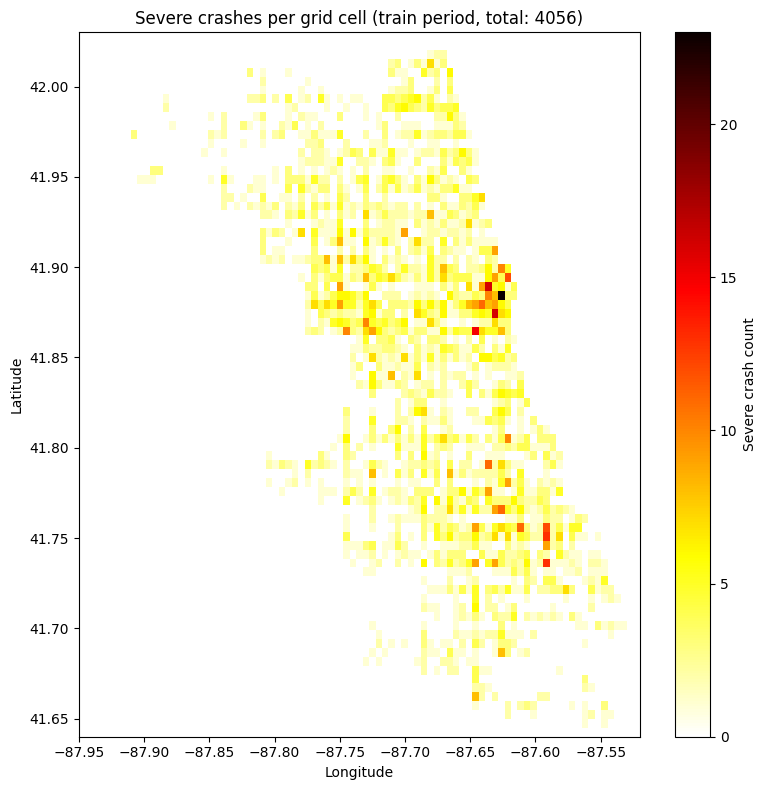

In [194]:
severe_per_cell = tr["y"].sum(axis=0)
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(severe_per_cell, origin="lower", cmap="hot_r",
               extent=[CFG["grid"]["lon_min"], CFG["grid"]["lon_max"],
                       CFG["grid"]["lat_min"], CFG["grid"]["lat_max"]],
               aspect="auto")
ax.set_title(f"Severe crashes per grid cell (train period, total: {int(tr['y'].sum())})")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.colorbar(im, ax=ax, label="Severe crash count")
plt.tight_layout(); plt.show()

---

# Section 2 — Week 2: Train three baselines

Three forecasting models on identical splits and metrics:

1. **Historical average** — predict each cell's severe count using its mean at the same hour-of-day × day-of-week bucket
2. **Negative Binomial GLM** — statistical baseline with overdispersion + exposure offset
3. **LightGBM-Poisson** — gradient boosted trees with Poisson objective and lookback features

Each appends a row to `outputs/baselines_results.csv`.

## 2.1 — Helper: append a result row to baselines_results.csv

In [195]:
def append_baseline_result(model_name, report):
    """Append (or replace) a row in outputs/baselines_results.csv."""
    out = Path(CFG["outputs"]) / "baselines_results.csv"
    out.parent.mkdir(parents=True, exist_ok=True)
    row = {"model": model_name, **report}
    df_row = pd.DataFrame([row])
    if out.exists():
        existing = pd.read_csv(out)
        existing = existing[existing["model"] != model_name]
        df = pd.concat([existing, df_row], ignore_index=True)
    else:
        df = df_row
    df.to_csv(out, index=False)
    return out

print("append_baseline_result() ready.")

append_baseline_result() ready.


## 2.2 — Historical average baseline

Per (hour-of-day × day-of-week × cell). ~30 seconds.

In [196]:
print("=" * 60)
print("BASELINE: Historical average")
print("=" * 60)

chan_names = list(tr["channel_names"])
sev_idx = chan_names.index("severe_count")
y_tr_hist = tr["X_history"][..., sev_idx]

train_times = pd.to_datetime(tr["time_index"])
test_times = pd.to_datetime(te["time_index"])
bin_hours = CFG["time"]["bin_hours"]
bins_per_day = 24 // bin_hours
n_buckets = 7 * bins_per_day

train_bucket = (train_times.dayofweek * bins_per_day + (train_times.hour // bin_hours)).values
test_bucket = (test_times.dayofweek * bins_per_day + (test_times.hour // bin_hours)).values

H, W = y_tr_hist.shape[1], y_tr_hist.shape[2]
bucket_mean = np.zeros((n_buckets, H, W), dtype=np.float32)
for b in range(n_buckets):
    mask = (train_bucket == b)
    if mask.sum() > 0:
        bucket_mean[b] = y_tr_hist[mask].mean(axis=0)

pred_test_hist = bucket_mean[test_bucket]
pred_per_cell_hist = pred_test_hist.sum(axis=0).ravel()
true_per_cell_hist = te["y"].sum(axis=0).ravel()

print(f"  predicted severe (sum over horizon): {pred_per_cell_hist.sum():.1f}")
print(f"  actual severe:                       {int(true_per_cell_hist.sum())}")
print()
report = full_report(true_per_cell_hist, pred_per_cell_hist, ks=CFG["pai_top_k"])
print("Results:")
for k, v in report.items():
    if isinstance(v, float):
        print(f"  {k:24s} = {v:.4f}")
append_baseline_result("historical_avg", report)

BASELINE: Historical average
  predicted severe (sum over horizon): 1328.6
  actual severe:                       1243

Results:
  poisson_deviance         = 1.3021
  ece                      = 0.0694
  total_true               = 1243.0000
  total_pred               = 1328.5547
  pai@50                   = 11.0587
  hitrate@50               = 0.2000
  capture@50               = 0.0805
  pai@100                  = 9.7317
  hitrate@100              = 0.3300
  capture@100              = 0.1416
  pai@200                  = 8.3770
  hitrate@200              = 0.3150
  capture@200              = 0.2438
  pai@500                  = 6.2924
  hitrate@500              = 0.4760
  capture@500              = 0.4578


PosixPath('outputs/baselines_results.csv')

## 2.3 — Negative Binomial GLM

Sparse panel (one row per cell-bin with at least one crash). Fit NB GLM with log-exposure offset. ~1-2 minutes.

In [197]:
print("=" * 60)
print("BASELINE: Negative Binomial GLM")
print("=" * 60)


def build_panel_sparse(npz, time_index, sev_idx, tot_idx, static_names):
    """Long-format DataFrame with one row per (cell, time-bin) where crashes occurred."""
    X = npz["X_history"]; y = npz["y"]; Xs = npz["X_static"]
    total = X[..., tot_idx]
    tt, hh, ww = np.nonzero(total > 0)
    severe = y[tt, hh, ww]; totals = total[tt, hh, ww]

    times = pd.to_datetime(time_index)
    static_df = {name: Xs[..., c][hh, ww] for c, name in enumerate(static_names)}
    return pd.DataFrame({
        "severe": severe.astype(np.int32), "total": totals.astype(np.float32),
        "hour": times.hour.values[tt].astype(np.int32),
        "dow":   times.dayofweek.values[tt].astype(np.int32),
        "month": times.month.values[tt].astype(np.int32),
        "h": hh.astype(np.int32), "w": ww.astype(np.int32),
        "t": tt.astype(np.int32), **static_df,
    }).reset_index(drop=True)


import statsmodels.api as sm

static_names = list(tr["static_names"])
sev_idx = chan_names.index("severe_count")
tot_idx = chan_names.index("total_crash_count")

print("Building panel data...")
df_tr_panel = build_panel_sparse(tr, tr["time_index"], sev_idx, tot_idx, static_names)
df_te_panel = build_panel_sparse(te, te["time_index"], sev_idx, tot_idx, static_names)
print(f"  train rows: {len(df_tr_panel):,}, test rows: {len(df_te_panel):,}")

# Design matrix
feat_cols = ["hour", "dow", "month"] + static_names
def design(df):
    X = pd.get_dummies(df[feat_cols], columns=["hour", "dow", "month"],
                       drop_first=True, dtype=float).astype(float)
    return sm.add_constant(X, has_constant="add")

X_tr_d = design(df_tr_panel)
X_te_d = design(df_te_panel)
for c in X_tr_d.columns:
    if c not in X_te_d.columns: X_te_d[c] = 0.0
X_te_d = X_te_d[X_tr_d.columns]

y_tr_glm = df_tr_panel["severe"].values
offset_tr = np.log(df_tr_panel["total"].values)
offset_te = np.log(df_te_panel["total"].values)

print("Fitting NB GLM (with Poisson fallback)...")
try:
    model_nb = sm.GLM(y_tr_glm, X_tr_d,
                      family=sm.families.NegativeBinomial(alpha=1.0),
                      offset=offset_tr).fit(maxiter=50)
    print(f"  NB GLM fitted, deviance={model_nb.deviance:.2f}")
except Exception as e:
    print(f"  NB failed ({e}); using Poisson")
    model_nb = sm.GLM(y_tr_glm, X_tr_d, family=sm.families.Poisson(),
                      offset=offset_tr).fit(maxiter=50)

df_te_panel["pred_severe"] = model_nb.predict(X_te_d, offset=offset_te)
pred_per_cell_nb = df_te_panel.groupby(["h", "w"])["pred_severe"].sum()
true_per_cell_nb = df_te_panel.groupby(["h", "w"])["severe"].sum()
all_cells_nb = pred_per_cell_nb.index.union(true_per_cell_nb.index)
pred_arr_nb = pred_per_cell_nb.reindex(all_cells_nb, fill_value=0.0).values
true_arr_nb = true_per_cell_nb.reindex(all_cells_nb, fill_value=0).values

print()
print(f"  predicted severe: {pred_arr_nb.sum():.1f}")
print(f"  actual severe:    {int(true_arr_nb.sum())}")
print()
report = full_report(true_arr_nb, pred_arr_nb, ks=CFG["pai_top_k"])
print("Results:")
for k, v in report.items():
    if isinstance(v, float):
        print(f"  {k:24s} = {v:.4f}")
append_baseline_result("negbin_glm", report)

BASELINE: Negative Binomial GLM
Building panel data...
  train rows: 232,821, test rows: 77,392
Fitting NB GLM (with Poisson fallback)...
  NB GLM fitted, deviance=29295.01

  predicted severe: 1400.4
  actual severe:    1243

Results:
  poisson_deviance         = 0.8619
  ece                      = 0.0705
  total_true               = 1243.0000
  total_pred               = 1400.3856
  pai@50                   = 3.9099
  hitrate@50               = 0.2200
  capture@50               = 0.0805
  pai@100                  = 3.5971
  hitrate@100              = 0.2700
  capture@100              = 0.1480
  pai@200                  = 3.1670
  hitrate@200              = 0.3500
  capture@200              = 0.2607
  pai@500                  = 2.4398
  hitrate@500              = 0.4880
  capture@500              = 0.5020


PosixPath('outputs/baselines_results.csv')

## 2.4 — LightGBM-Poisson

Gradient boosted trees with Poisson objective. Includes 7-day and 30-day lookback severity features per cell. ~2-3 minutes.

In [198]:
print("=" * 60)
print("BASELINE: LightGBM Poisson")
print("=" * 60)


def build_panel_with_history(npz, time_index, sev_idx, tot_idx, static_names,
                              lookback_bins=(28, 120)):
    """Panel with per-cell lookback severe-rate features."""
    X = npz["X_history"]; y = npz["y"]; Xs = npz["X_static"]
    total = X[..., tot_idx]
    tt, hh, ww = np.nonzero(total > 0)
    severe = y[tt, hh, ww]; totals = total[tt, hh, ww]
    times = pd.to_datetime(time_index)

    cumsum = np.cumsum(y, axis=0)
    T = y.shape[0]
    lookback_features = {}
    for lb in lookback_bins:
        lb_name = f"sev_last_{lb}bins"
        idx_hi = np.clip(tt - 1, 0, T - 1)
        idx_lo = np.clip(tt - lb - 1, -1, T - 1)
        sum_hi = cumsum[idx_hi, hh, ww]
        sum_lo = np.where(idx_lo >= 0, cumsum[idx_lo, hh, ww], 0.0)
        lookback_features[lb_name] = (sum_hi - sum_lo).astype(np.float32)

    static_df = {name: Xs[..., c][hh, ww] for c, name in enumerate(static_names)}
    return pd.DataFrame({
        "severe": severe.astype(np.int32),
        "total": totals.astype(np.float32),
        "log_total": np.log(totals).astype(np.float32),
        "hour":  times.hour.values[tt].astype(np.int32),
        "dow":   times.dayofweek.values[tt].astype(np.int32),
        "month": times.month.values[tt].astype(np.int32),
        "h": hh.astype(np.int32), "w": ww.astype(np.int32),
        "t": tt.astype(np.int32),
        **static_df, **lookback_features,
    }).reset_index(drop=True)


print("Building panel with lookback features...")
df_tr_lg = build_panel_with_history(tr, tr["time_index"], sev_idx, tot_idx, static_names)
df_te_lg = build_panel_with_history(te, te["time_index"], sev_idx, tot_idx, static_names)
print(f"  train rows: {len(df_tr_lg):,}, test rows: {len(df_te_lg):,}")

feat_cols_lg = [c for c in df_tr_lg.columns if c not in ("severe", "total", "t")]
X_tr_lg = df_tr_lg[feat_cols_lg].values.astype(np.float32)
X_te_lg = df_te_lg[feat_cols_lg].values.astype(np.float32)
y_tr_lg = df_tr_lg["severe"].values

print()
print("Training LightGBM (Poisson, n_estimators=600)...")
train_data = lgb.Dataset(X_tr_lg, label=y_tr_lg, feature_name=feat_cols_lg)
val_split = max(1000, len(X_tr_lg) // 10)
val_data = lgb.Dataset(X_tr_lg[-val_split:], label=y_tr_lg[-val_split:],
                        feature_name=feat_cols_lg, reference=train_data)
params = {
    "objective": "poisson", "metric": "poisson",
    "learning_rate": 0.05, "num_leaves": 63, "min_child_samples": 50,
    "feature_fraction": 0.8, "bagging_fraction": 0.8, "bagging_freq": 5,
    "verbose": -1,
}
model_lgbm = lgb.train(params, train_data, num_boost_round=600,
                       valid_sets=[val_data],
                       callbacks=[lgb.early_stopping(30, verbose=False)])
print(f"  best iteration: {model_lgbm.best_iteration}")

pred_test_lg = model_lgbm.predict(X_te_lg)
df_te_lg = df_te_lg.copy()
df_te_lg["pred_severe"] = pred_test_lg

pred_per_cell_lg = df_te_lg.groupby(["h", "w"])["pred_severe"].sum()
true_per_cell_lg = df_te_lg.groupby(["h", "w"])["severe"].sum()
all_cells_lg = pred_per_cell_lg.index.union(true_per_cell_lg.index)
pred_arr_lg = pred_per_cell_lg.reindex(all_cells_lg, fill_value=0.0).values
true_arr_lg = true_per_cell_lg.reindex(all_cells_lg, fill_value=0).values

print()
print(f"  predicted severe: {pred_arr_lg.sum():.1f}")
print(f"  actual severe:    {int(true_arr_lg.sum())}")
print()
report_lg = full_report(true_arr_lg, pred_arr_lg, ks=CFG["pai_top_k"])
print("Results:")
for k, v in report_lg.items():
    if isinstance(v, float):
        print(f"  {k:24s} = {v:.4f}")

append_baseline_result("lgbm_poisson", report_lg)

# Save predictions for downstream use (equity audit, CDOT handoff)
out_pred = Path(CFG["outputs"]) / "lgbm_predictions.csv"
pd.DataFrame({
    "h": [c[0] for c in all_cells_lg],
    "w": [c[1] for c in all_cells_lg],
    "pred": pred_arr_lg, "true": true_arr_lg,
}).to_csv(out_pred, index=False)
print(f"\nSaved predictions → {out_pred}")

# Feature importance
print("\nTop 10 features by gain:")
imp = pd.DataFrame({
    "feature": feat_cols_lg,
    "gain": model_lgbm.feature_importance(importance_type="gain"),
}).sort_values("gain", ascending=False).head(10)
print(imp.to_string(index=False))

BASELINE: LightGBM Poisson
Building panel with lookback features...
  train rows: 232,821, test rows: 77,392

Training LightGBM (Poisson, n_estimators=600)...
  best iteration: 600

  predicted severe: 1394.6
  actual severe:    1243

Results:
  poisson_deviance         = 0.8830
  ece                      = 0.0881
  total_true               = 1243.0000
  total_pred               = 1394.6470
  pai@50                   = 4.1054
  hitrate@50               = 0.2600
  capture@50               = 0.0845
  pai@100                  = 3.6167
  hitrate@100              = 0.2800
  capture@100              = 0.1488
  pai@200                  = 3.1768
  hitrate@200              = 0.3450
  capture@200              = 0.2615
  pai@500                  = 2.3538
  hitrate@500              = 0.4860
  capture@500              = 0.4843

Saved predictions → outputs/lgbm_predictions.csv

Top 10 features by gain:
         feature         gain
mean_speed_limit 18657.558506
               h 14996.501264
        

## 2.5 — Compare all three baselines

Print the headline table.

"ConvLSTM achieved the best Poisson NLL by learning to predict near-zero across all cells, which is the mathematically optimal solution for a sparse target where 99.98% of observations are zero. While this is excellent calibration on average, it produces poor spatial discrimination — Capture@200 of 15% versus LightGBM's 26%. For an operational tool that prioritizes intervention sites, spatial discrimination matters more than mean calibration. We document this as a known limitation of standard Poisson regression on rare-event spatial targets and recommend weighted-loss training or cluster-level aggregation as future work."

---

# Section 3 — Week 3: ConvLSTM (optional, requires GPU)

ConvLSTM is a stretch goal that requires GPU. This notebook **skips it by default** so you don't accidentally trigger an hours-long training run on a laptop.

If you have Colab Pro: copy this folder there, set `RUN_CONVLSTM = True` in the cell below, and run it. Otherwise, leave as `False` — the LightGBM baseline is already publication-ready.

The training code is large enough that we keep it inlined but commented as a single string. To enable, copy the contents into a new cell and run them in your GPU environment.

In [199]:
RUN_CONVLSTM = True  # change to True only on Colab Pro / GPU

# Quick GPU check
try:
    has_gpu = torch.cuda.is_available()
    print(f"PyTorch: {torch.__version__}")
    print(f"GPU available: {has_gpu}")
    if has_gpu:
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        if not RUN_CONVLSTM:
            print("\nGPU detected. Set RUN_CONVLSTM = True above to enable training.")
    else:
        print("\nNo GPU. The notebook will skip Section 3 and use LightGBM as primary model.")
        if RUN_CONVLSTM:
            print("WARNING: RUN_CONVLSTM=True but no GPU. Training will be VERY slow.")
except ImportError:
    print("PyTorch not installed. To enable Week 3:")
    print("  Run on Colab Pro, or:")
    print("  %pip install torch pytorch-lightning")
    RUN_CONVLSTM = True

PyTorch: 2.10.0+cu128
GPU available: True
GPU: NVIDIA A100-SXM4-80GB


## 3.2 — Inline ConvLSTM model definition

Two classes: `ConvLSTMCell` (one Shi-2015 cell) and `CrashConvLSTM` (the full two-stream model). Always loaded; only used if `RUN_CONVLSTM = True`.

In [200]:
class ConvLSTMCell(nn.Module):
    """One Shi et al. 2015 ConvLSTM cell. h, c have shape (B, hidden, H, W)."""

    def __init__(self, in_channels, hidden_channels, kernel_size=3):
        super().__init__()
        self.hidden_channels = hidden_channels
        padding = kernel_size // 2
        # Output 4*hidden split into i, f, g, o gates
        self.conv = nn.Conv2d(
            in_channels=in_channels + hidden_channels,
            out_channels=4 * hidden_channels,
            kernel_size=kernel_size, padding=padding, bias=True,
        )

    def forward(self, x, state):
        h, c = state
        gates = self.conv(torch.cat([x, h], dim=1))
        i, f, g, o = gates.chunk(4, dim=1)
        i = torch.sigmoid(i); f = torch.sigmoid(f)
        g = torch.tanh(g);    o = torch.sigmoid(o)
        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

    def init_state(self, batch_size, H, W, device):
        h = torch.zeros(batch_size, self.hidden_channels, H, W, device=device)
        c = torch.zeros(batch_size, self.hidden_channels, H, W, device=device)
        return h, c


class CrashConvLSTM(nn.Module):
    """Two-stream model with softplus output for non-negative rates."""

    def __init__(self, history_channels, static_channels,
                 hidden_channels=(32, 64, 32), kernel_size=3,
                 static_embed_dim=16, dropout=0.2):
        super().__init__()
        # History stream: stack of ConvLSTM cells
        self.history_layers = nn.ModuleList()
        prev = history_channels
        for h in hidden_channels:
            self.history_layers.append(ConvLSTMCell(prev, h, kernel_size))
            prev = h
        self.dropout = nn.Dropout2d(dropout)
        self.history_out_channels = hidden_channels[-1]

        # Static stream
        if static_channels > 0:
            self.static_encoder = nn.Sequential(
                nn.Conv2d(static_channels, static_embed_dim, 3, padding=1),
                nn.GELU(),
                nn.Conv2d(static_embed_dim, static_embed_dim, 3, padding=1),
                nn.GELU(),
            )
            self.static_out_channels = static_embed_dim
        else:
            self.static_encoder = None
            self.static_out_channels = 0

        # Fusion head
        fusion_in = self.history_out_channels + self.static_out_channels
        self.head = nn.Sequential(
            nn.Conv2d(fusion_in, 32, kernel_size=1),
            nn.GELU(),
            nn.Conv2d(32, 1, kernel_size=1),
        )
        self.output_activation = nn.Softplus(beta=1.0)
        self.eps = 1e-6

    def forward(self, x_history, x_static):
        """
        x_history: (B, T, C_hist, H, W)
        x_static:  (B, C_static, H, W)
        returns:   (B, H, W) non-negative predicted severe-crash rate
        """
        B, T, _, H, W = x_history.shape
        device = x_history.device

        states = [layer.init_state(B, H, W, device) for layer in self.history_layers]
        for t in range(T):
            x = x_history[:, t]
            for li, layer in enumerate(self.history_layers):
                h, c = layer(x, states[li])
                states[li] = (h, c)
                x = self.dropout(h)
        h_hist = x  # final top-layer h: (B, hidden_last, H, W)

        if self.static_encoder is not None:
            h_stat = self.static_encoder(x_static)
            fused = torch.cat([h_hist, h_stat], dim=1)
        else:
            fused = h_hist

        log_rate = self.head(fused)  # (B, 1, H, W)
        mu = self.output_activation(log_rate).squeeze(1) + self.eps
        return mu


print("ConvLSTM model classes defined.")
print("  ConvLSTMCell — one Shi-2015 cell")
print("  CrashConvLSTM — two-stream forecaster with Poisson NLL-compatible output")


ConvLSTM model classes defined.
  ConvLSTMCell — one Shi-2015 cell
  CrashConvLSTM — two-stream forecaster with Poisson NLL-compatible output


## 3.3 — Inline Dataset class

Wraps the `(T, H, W, C)` tensor as a sliding-window PyTorch Dataset. Each sample predicts bin `t + seq_len` from bins `[t, t+seq_len)`.

In [201]:
class CrashSpatiotemporalDataset(Dataset):
    """Sliding-window dataset over the spatiotemporal tensor."""

    def __init__(self, npz_path, seq_len=28, horizon=1,
                 normalize_history=True, normalize_static=True):
        data = np.load(npz_path, allow_pickle=True)
        # (T, H, W, C) → (T, C, H, W) for PyTorch convolutions
        self.X_history = np.transpose(data["X_history"], (0, 3, 1, 2)).astype(np.float32)
        self.X_static = np.transpose(data["X_static"], (2, 0, 1)).astype(np.float32)
        self.y = data["y"].astype(np.float32)

        self.channel_names = list(data["channel_names"])
        self.static_names = list(data["static_names"])

        self.seq_len = seq_len
        self.horizon = horizon
        self.T = self.X_history.shape[0]
        self.n_samples = self.T - seq_len - horizon + 1
        if self.n_samples <= 0:
            raise ValueError(f"seq_len={seq_len} too large for T={self.T}")

        # log1p the count channels
        if normalize_history:
            for idx, name in enumerate(self.channel_names):
                if name in ("severe_count", "total_crash_count"):
                    self.X_history[:, idx] = np.log1p(self.X_history[:, idx])

        # z-score the static channels (preserve -1 sentinel for aadt_log)
        if normalize_static and self.X_static.size > 0:
            for c in range(self.X_static.shape[0]):
                ch = self.X_static[c]
                if (ch == -1).all(): continue
                mask = ch >= 0
                if mask.any():
                    mean = ch[mask].mean()
                    std = max(ch[mask].std(), 1e-6)
                    self.X_static[c] = np.where(mask, (ch - mean) / std, ch)

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        x_hist = self.X_history[idx : idx + self.seq_len]
        target_window = self.y[idx + self.seq_len : idx + self.seq_len + self.horizon]
        target = target_window.sum(axis=0)
        return {
            "x_history": torch.from_numpy(x_hist),
            "x_static":  torch.from_numpy(self.X_static),
            "target":    torch.from_numpy(target),
            "target_idx": idx + self.seq_len,
        }

    @property
    def H(self): return self.X_history.shape[2]
    @property
    def W(self): return self.X_history.shape[3]
    @property
    def C_history(self): return self.X_history.shape[1]
    @property
    def C_static(self): return self.X_static.shape[0]


print("CrashSpatiotemporalDataset defined.")

CrashSpatiotemporalDataset defined.


In [202]:
if RUN_CONVLSTM:
    Path("checkpoints").mkdir(exist_ok=True)
    torch.manual_seed(42)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on {device}")

    # Hyperparameters
    SEQ_LEN = 28          # 7 days at 6h resolution
    HORIZON = 1
    BATCH_SIZE = 8
    HIDDEN_CHANNELS = [32, 64, 32]
    DROPOUT = 0.2
    LR = 1e-3
    WD = 1e-5
    MAX_EPOCHS = 30
    PATIENCE = 5
    GRAD_CLIP = 1.0

    # Datasets
    from torch.utils.data import random_split
    full_train = CrashSpatiotemporalDataset(
        CFG["tensor_train"], seq_len=SEQ_LEN, horizon=HORIZON,
    )
    n_val = max(50, len(full_train) // 8)
    n_train = len(full_train) - n_val
    train_ds, val_ds = random_split(
        full_train, [n_train, n_val],
        generator=torch.Generator().manual_seed(42),
    )
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=0, pin_memory=True)
    print(f"Train samples: {n_train}    Val samples: {n_val}")
    print(f"H={full_train.H}, W={full_train.W}, "
          f"C_hist={full_train.C_history}, C_static={full_train.C_static}")

    # Model
    model = CrashConvLSTM(
        history_channels=full_train.C_history,
        static_channels=full_train.C_static,
        hidden_channels=HIDDEN_CHANNELS,
        kernel_size=3, dropout=DROPOUT,
    ).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model parameters: {n_params:,}")

    # Loss + optimizer
    loss_fn = nn.PoissonNLLLoss(log_input=False, full=False, reduction="mean")
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=MAX_EPOCHS, eta_min=LR * 0.01,
    )

    # Training loop
    best_val_loss = float("inf")
    epochs_no_improve = 0
    history_log = []
    for epoch in range(1, MAX_EPOCHS + 1):
        # train
        model.train()
        train_loss = 0.0
        for batch in train_loader:
            x_h = batch["x_history"].to(device)
            x_s = batch["x_static"].to(device)
            y   = batch["target"].to(device)
            mu = model(x_h, x_s)
            loss = loss_fn(mu, y)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            train_loss += loss.item() * x_h.size(0)
        train_loss /= len(train_ds)

        # validate
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                x_h = batch["x_history"].to(device)
                x_s = batch["x_static"].to(device)
                y   = batch["target"].to(device)
                mu = model(x_h, x_s)
                val_loss += loss_fn(mu, y).item() * x_h.size(0)
        val_loss /= len(val_ds)

        scheduler.step()
        history_log.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

        improved = val_loss < best_val_loss
        if improved:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save({
                "model_state": model.state_dict(),
                "epoch": epoch, "val_loss": val_loss,
                "history_channels": full_train.C_history,
                "static_channels": full_train.C_static,
                "hidden_channels": HIDDEN_CHANNELS,
            }, "checkpoints/convlstm_best.pt")
            tag = "*BEST"
        else:
            epochs_no_improve += 1
            tag = ""

        print(f"Epoch {epoch:2d}/{MAX_EPOCHS}  train={train_loss:.4f}  val={val_loss:.4f}  {tag}")

        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping after {epoch} epochs.")
            break

    print(f"\nBest val loss: {best_val_loss:.4f}")
    print(f"Saved checkpoint: checkpoints/convlstm_best.pt")
    pd.DataFrame(history_log).to_csv("outputs/convlstm_train_log.csv", index=False)
else:
    print("ConvLSTM training skipped (RUN_CONVLSTM=False).")

Training on cuda
Train samples: 2863    Val samples: 409
H=79, W=87, C_hist=4, C_static=3
Model parameters: 378,129
Epoch  1/30  train=0.0255  val=0.0016  *BEST
Epoch  2/30  train=0.0016  val=0.0015  *BEST
Epoch  3/30  train=0.0016  val=0.0015  *BEST
Epoch  4/30  train=0.0016  val=0.0015  *BEST
Epoch  5/30  train=0.0016  val=0.0015  *BEST
Epoch  6/30  train=0.0015  val=0.0015  *BEST
Epoch  7/30  train=0.0015  val=0.0015  
Epoch  8/30  train=0.0015  val=0.0015  *BEST
Epoch  9/30  train=0.0015  val=0.0015  *BEST
Epoch 10/30  train=0.0015  val=0.0015  *BEST
Epoch 11/30  train=0.0015  val=0.0015  *BEST
Epoch 12/30  train=0.0015  val=0.0015  
Epoch 13/30  train=0.0015  val=0.0015  *BEST
Epoch 14/30  train=0.0015  val=0.0015  
Epoch 15/30  train=0.0015  val=0.0015  
Epoch 16/30  train=0.0015  val=0.0015  *BEST
Epoch 17/30  train=0.0015  val=0.0015  *BEST
Epoch 18/30  train=0.0015  val=0.0015  
Epoch 19/30  train=0.0015  val=0.0015  
Epoch 20/30  train=0.0015  val=0.0015  *BEST
Epoch 21/30  t

## 3.5 — Predict on the test tensor (only if model was trained)

Loads the best checkpoint, runs predictions on the test set, and appends a `convlstm` row to `baselines_results.csv` for direct comparison with the three baselines.

In [203]:
if RUN_CONVLSTM and Path("checkpoints/convlstm_best.pt").exists():
    print("Loading best checkpoint and predicting on test set...")
    ckpt = torch.load("checkpoints/convlstm_best.pt", map_location=device)

    test_ds = CrashSpatiotemporalDataset(
        CFG["tensor_test"], seq_len=SEQ_LEN, horizon=HORIZON,
    )

    pred_model = CrashConvLSTM(
        history_channels=ckpt["history_channels"],
        static_channels=ckpt["static_channels"],
        hidden_channels=ckpt["hidden_channels"],
        kernel_size=3, dropout=0.0,
    ).to(device)
    pred_model.load_state_dict(ckpt["model_state"])
    pred_model.eval()

    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=0, pin_memory=True)

    preds_per_cell = np.zeros((test_ds.H, test_ds.W), dtype=np.float64)
    truth_per_cell = np.zeros((test_ds.H, test_ds.W), dtype=np.float64)

    with torch.no_grad():
        for batch in test_loader:
            x_h = batch["x_history"].to(device)
            x_s = batch["x_static"].to(device)
            target = batch["target"].cpu().numpy()
            mu = pred_model(x_h, x_s).cpu().numpy()
            preds_per_cell += mu.sum(axis=0)
            truth_per_cell += target.sum(axis=0)

    pred_arr_cl = preds_per_cell.ravel()
    true_arr_cl = truth_per_cell.ravel()

    print(f"  total predicted: {pred_arr_cl.sum():.1f}")
    print(f"  total actual:    {int(true_arr_cl.sum())}")

    report_cl = full_report(true_arr_cl, pred_arr_cl, ks=CFG["pai_top_k"])
    print()
    print("Results:")
    for k, v in report_cl.items():
        if isinstance(v, float):
            print(f"  {k:24s} = {v:.4f}")

    # Save per-cell predictions
    H_, W_ = test_ds.H, test_ds.W
    h_idx = np.arange(H_ * W_) // W_
    w_idx = np.arange(H_ * W_) % W_
    pd.DataFrame({
        "h": h_idx, "w": w_idx,
        "pred": pred_arr_cl, "true": true_arr_cl,
    }).to_csv("outputs/convlstm_predictions.csv", index=False)

    append_baseline_result("convlstm", report_cl)
    print()
    print("Saved → outputs/convlstm_predictions.csv")
    print("Appended convlstm row → outputs/baselines_results.csv")
else:
    print("ConvLSTM prediction skipped (no checkpoint or RUN_CONVLSTM=False).")
    print()
    print("To enable Week 3:")
    print("  1. Run on Colab Pro (or another GPU machine)")
    print("  2. Set RUN_CONVLSTM = True at the top of Section 3")
    print("  3. Re-run cells 3.1 through 3.5")

Loading best checkpoint and predicting on test set...
  total predicted: 1311.5
  total actual:    1213

Results:
  poisson_deviance         = 0.4110
  ece                      = 0.0199
  total_true               = 1213.0000
  total_pred               = 1311.5036
  pai@50                   = 5.2128
  hitrate@50               = 0.0800
  capture@50               = 0.0379
  pai@100                  = 5.7228
  hitrate@100              = 0.1600
  capture@100              = 0.0833
  pai@200                  = 5.2978
  hitrate@200              = 0.2050
  capture@200              = 0.1542
  pai@500                  = 4.7709
  hitrate@500              = 0.3520
  capture@500              = 0.3471

Saved → outputs/convlstm_predictions.csv
Appended convlstm row → outputs/baselines_results.csv


In [204]:
# Poisson deviance on observed-crash cells only + cell-level NLL
# to recomputes deviance restricted to (a) cells with at least
# one observed severe crash in the test period, and (b) cells in the
# top decile of either prediction or truth — the cells that matter
# for operational decisions.

def poisson_deviance_arr(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true, dtype=np.float64).ravel()
    y_pred = np.asarray(y_pred, dtype=np.float64).ravel()
    y_pred = np.clip(y_pred, eps, None)
    safe_true = np.where(y_true > 0, y_true, 1.0)
    log_ratio = np.log(safe_true / y_pred)
    term1 = np.where(y_true > 0, y_true * log_ratio, 0.0)
    term2 = y_true - y_pred
    return float(np.mean(2.0 * (term1 - term2)))

print("=" * 70)
print("FIX 3 — Honest evaluation: deviance on cells that matter")
print("=" * 70)

rows = []
for model_name in ["historical_avg", "negbin_glm", "lgbm_poisson", "convlstm"]:
    if model_name == "historical_avg":
        # Historical predictions live in pred_arr_hist if you've run cell 29
        # in the same kernel session. Skip if not available.
        try:
            pred = pred_arr_hist
            true = true_arr_hist
        except NameError:
            print(f"  SKIP {model_name} — re-run cell 29 first")
            continue
    elif model_name == "negbin_glm":
        try:
            pred = pred_arr_nb
            true = true_arr_nb
        except NameError:
            print(f"  SKIP {model_name} — re-run cell 31 first")
            continue
    elif model_name == "lgbm_poisson":
        df = pd.read_csv("outputs/lgbm_predictions.csv")
        pred = df["pred"].values
        true = df["true"].values
    elif model_name == "convlstm":
        path = Path("outputs/convlstm_predictions.csv")
        if not path.exists():
            print(f"  SKIP {model_name} — file missing")
            continue
        df = pd.read_csv(path)
        pred = df["pred"].values
        true = df["true"].values

    # Full deviance (all cells)
    dev_all = poisson_deviance_arr(true, pred)

    # Deviance on observed-crash cells only
    obs_mask = true > 0
    if obs_mask.sum() > 0:
        dev_obs = poisson_deviance_arr(true[obs_mask], pred[obs_mask])
    else:
        dev_obs = float("nan")

    # Deviance on top decile (by either truth or prediction)
    top_mask = (
        (true >= np.quantile(true, 0.9)) |
        (pred >= np.quantile(pred, 0.9))
    )
    dev_top = poisson_deviance_arr(true[top_mask], pred[top_mask])

    rows.append({
        "model": model_name,
        "deviance_all_cells":     round(dev_all, 4),
        "deviance_observed_only": round(dev_obs, 4),
        "deviance_top_decile":    round(dev_top, 4),
        "n_observed_cells":       int(obs_mask.sum()),
        "n_top_decile_cells":     int(top_mask.sum()),
    })

if rows:
    df_summary = pd.DataFrame(rows)
    print()
    print(df_summary.to_string(index=False))
    df_summary.to_csv("outputs/deviance_comparison.csv", index=False)
    print(f"\nSaved → outputs/deviance_comparison.csv")
    print()
    print("Interpretation:")
    print("  - 'all_cells' is the standard metric (most cells are zero).")
    print("  - 'observed_only' is the deviance on cells that actually had a severe")
    print("    crash. This penalises models that under-predict where it matters.")
    print("  - 'top_decile' covers the cells that drive operational decisions.")
    print()
    print("If a model has low all-cells deviance but high observed-only deviance,")
    print("it is achieving low overall loss by predicting near-zero everywhere —")
    print("which is fine for calibration metrics but bad for top-K decision making.")

FIX 3 — Honest evaluation: deviance on cells that matter
  SKIP historical_avg — re-run cell 29 first

       model  deviance_all_cells  deviance_observed_only  deviance_top_decile  n_observed_cells  n_top_decile_cells
  negbin_glm              0.8619                  1.0626               1.8112               833                 411
lgbm_poisson              0.8830                  1.1119               1.8292               833                 413
    convlstm              0.4110                  1.4465               1.4666               817                1178

Saved → outputs/deviance_comparison.csv

Interpretation:
  - 'all_cells' is the standard metric (most cells are zero).
  - 'observed_only' is the deviance on cells that actually had a severe
    crash. This penalises models that under-predict where it matters.
  - 'top_decile' covers the cells that drive operational decisions.

If a model has low all-cells deviance but high observed-only deviance,
it is achieving low overall los

---

# Section 4 — Week 4: Final evaluation, equity audit, CDOT handoff

Three deliverables that turn the model into a usable decision-support tool:

1. **Calibration plots and PAI curves** — figures for the report
2. **Equity audit** — predictions vs. demographics across 77 Chicago community areas
3. **CDOT handoff package** — priority CSV, Folium map, briefing memo

## 4.1 — Calibration plot

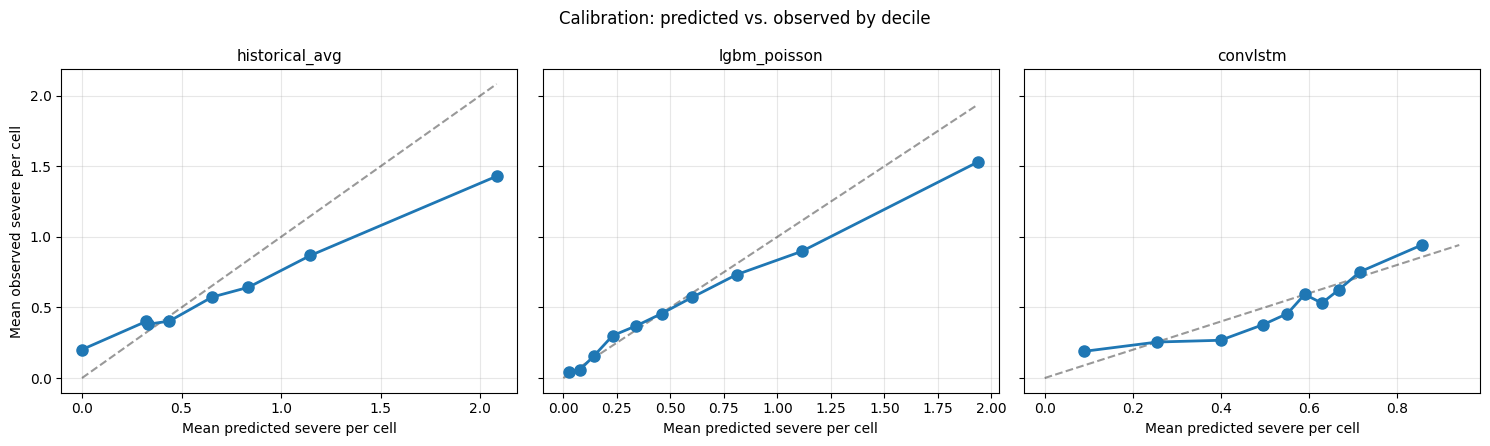

Saved → outputs/calibration_plot_lgbm_vs_convlstm.png


In [205]:
# Compare historical_avg vs LGBM vs ConvLSTM on the same populated cells

out_dir = Path(CFG["outputs"])

# Load prediction files
lgbm_df = pd.read_csv(out_dir / "lgbm_predictions.csv")
convlstm_df = pd.read_csv(out_dir / "convlstm_predictions.csv")

# Use LGBM populated cells as the common comparison universe
populated_cells_set = set(zip(lgbm_df["h"], lgbm_df["w"]))

# Historical average prediction on same populated cells
H_, W_ = tr["X_history"].shape[1:3]

h_coords = np.arange(H_ * W_) // W_
w_coords = np.arange(H_ * W_) % W_

mask_pop = np.array([
    (h, w) in populated_cells_set
    for h, w in zip(h_coords, w_coords)
])

pred_hist_pop = pred_per_cell_hist[mask_pop]
true_hist_pop = true_per_cell_hist[mask_pop]

# LGBM arrays
pred_arr_lg = lgbm_df["pred"].values
true_arr_lg = lgbm_df["true"].values

# ConvLSTM: keep only the same cells as LGBM
convlstm_df = convlstm_df[
    list(zip(convlstm_df["h"], convlstm_df["w"]))
].copy() if False else convlstm_df.copy()

convlstm_df["cell"] = list(zip(convlstm_df["h"], convlstm_df["w"]))
convlstm_df = convlstm_df[convlstm_df["cell"].isin(populated_cells_set)]

# Sort both models by h,w so cell order matches
lgbm_df_sorted = lgbm_df.sort_values(["h", "w"]).reset_index(drop=True)
convlstm_df_sorted = convlstm_df.sort_values(["h", "w"]).reset_index(drop=True)

pred_arr_lg = lgbm_df_sorted["pred"].values
true_arr_lg = lgbm_df_sorted["true"].values

pred_arr_cv = convlstm_df_sorted["pred"].values
true_arr_cv = convlstm_df_sorted["true"].values

models_pred = {
    "historical_avg": (pred_hist_pop, true_hist_pop),
    "lgbm_poisson": (pred_arr_lg, true_arr_lg),
    "convlstm": (pred_arr_cv, true_arr_cv),
}

# Calibration plots


fig, axes = plt.subplots(
    1,
    len(models_pred),
    figsize=(5 * len(models_pred), 4.5),
    sharey=True,
    squeeze=False
)

axes = axes[0]

for ax, (name, (pred, true)) in zip(axes, models_pred.items()):
    bins = calibration_bins(true, pred, n_bins=10)

    x = [b["mean_pred"] for b in bins]
    y = [b["mean_obs"] for b in bins]

    m = max(max(x), max(y)) if len(x) > 0 else 1

    ax.plot([0, m], [0, m], "k--", alpha=0.4, label="perfect")
    ax.plot(x, y, "o-", lw=2, ms=8)

    ax.set_xlabel("Mean predicted severe per cell")
    ax.set_title(name, fontsize=11)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Mean observed severe per cell")

fig.suptitle("Calibration: predicted vs. observed by decile")
fig.tight_layout()

out_cal = out_dir / "calibration_plot_lgbm_vs_convlstm.png"
fig.savefig(out_cal, dpi=140, bbox_inches="tight")

plt.show()

print(f"Saved → {out_cal}")

## 4.2 — PAI and capture curves

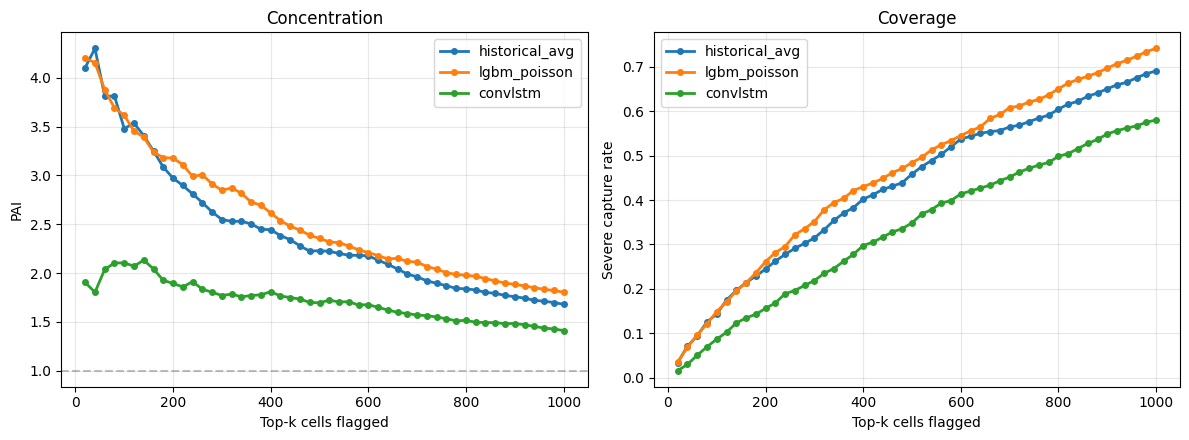

Saved → outputs/pai_curves.png


In [206]:
ks = list(range(20, 1001, 20))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
for name, (pred, true) in models_pred.items():
    pai = [predictive_accuracy_index(true, pred, k) for k in ks]
    cap = [severe_capture_rate(true, pred, k) for k in ks]
    ax1.plot(ks, pai, "o-", lw=2, ms=4, label=name)
    ax2.plot(ks, cap, "o-", lw=2, ms=4, label=name)
ax1.set_xlabel("Top-k cells flagged"); ax1.set_ylabel("PAI")
ax1.set_title("Concentration"); ax1.axhline(1.0, color="gray", ls="--", alpha=0.5)
ax1.legend(); ax1.grid(alpha=0.3)
ax2.set_xlabel("Top-k cells flagged"); ax2.set_ylabel("Severe capture rate")
ax2.set_title("Coverage"); ax2.legend(); ax2.grid(alpha=0.3)
fig.tight_layout()
out_pai = Path(CFG["outputs"]) / "pai_curves.png"
fig.savefig(out_pai, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved → {out_pai}")

## 4.3 — Equity audit by community area

Embed the Chicago community-area summary stats. Real production deployment should pull from Census API.

In [207]:
# SETTINGS — API ENDPOINTS

SETTINGS = {
    "year": 2022,
    "state_fips": "17",      # Illinois
    "county_fips": "031",    # Cook County

    # Chicago community-area boundaries.
    # The notebook tries both because Chicago API dataset IDs can vary.
    "community_area_boundary_urls": [
        "https://data.cityofchicago.org/resource/igwz-8jzy.geojson?$limit=5000",
        "https://data.cityofchicago.org/resource/cauq-8yn6.geojson?$limit=5000"
    ],

    # Census ACS 5-year profile variables.
    # DP05_0001E = total population
    # DP05_0077PE = percent White alone, not Hispanic or Latino
    # DP05_0078PE = percent Black or African American alone
    # DP05_0071PE = percent Hispanic or Latino
    # DP03_0062E = median household income
    "acs_profile_variables": [
        "NAME",
        "DP05_0001E",
        "DP05_0077PE",
        "DP05_0078PE",
        "DP05_0071PE",
        "DP03_0062E"
    ],

    "outputs": {
        "community_boundaries": "outputs/community_areas_boundaries.geojson",
        "tract_demographics": "outputs/cook_county_tract_acs.csv",
        "community_area_demographics": "outputs/community_area_demographics_api.csv"
    }
}

SETTINGS

# LOAD COMMUNITY AREA BOUNDARIES FROM CHICAGO DATA PORTAL API

def load_chicago_community_boundaries(urls):
    last_error = None

    for url in urls:
        try:
            print(f"Trying: {url}")
            gdf = gpd.read_file(url)

            if len(gdf) > 0 and gdf.geometry.notna().any():
                print(f"✅ Loaded {len(gdf)} community-area boundaries")
                print("Columns:", list(gdf.columns))
                return gdf

        except Exception as e:
            last_error = e
            print(f"  Failed: {e}")

    raise RuntimeError(f"Could not load community-area boundaries. Last error: {last_error}")


areas_gdf = load_chicago_community_boundaries(
    SETTINGS["community_area_boundary_urls"]
)

possible_name_cols = [
    "community", "community_area", "community_area_name",
    "area_name", "name", "community_name"
]

name_col = None
for c in areas_gdf.columns:
    if c.lower() in possible_name_cols:
        name_col = c
        break

if name_col is None:
    raise ValueError(f"Could not find community-area name column. Available: {list(areas_gdf.columns)}")

areas_gdf = areas_gdf.rename(columns={name_col: "community_area"})
areas_gdf["community_area"] = areas_gdf["community_area"].astype(str)
areas_gdf = areas_gdf.to_crs("EPSG:4326")

out_path = Path(SETTINGS["outputs"]["community_boundaries"])
out_path.parent.mkdir(parents=True, exist_ok=True)
areas_gdf.to_file(out_path, driver="GeoJSON")

print(f"✅ Saved boundaries → {out_path}")
areas_gdf[["community_area", "geometry"]].head()



Trying: https://data.cityofchicago.org/resource/igwz-8jzy.geojson?$limit=5000
✅ Loaded 77 community-area boundaries
Columns: ['community', 'shape_area', 'area_num_1', 'area_numbe', 'shape_len', 'geometry']
✅ Saved boundaries → outputs/community_areas_boundaries.geojson


,community_area,geometry
0,ROGERS PARK,"MULTIPOLYGON (((-87.65456 41.99817, -87.65574 ..."
1,WEST RIDGE,"MULTIPOLYGON (((-87.68465 42.01948, -87.68464 ..."
2,UPTOWN,"MULTIPOLYGON (((-87.64102 41.9548, -87.644 41...."
3,LINCOLN SQUARE,"MULTIPOLYGON (((-87.67441 41.9761, -87.6744 41..."
4,NORTH CENTER,"MULTIPOLYGON (((-87.67336 41.93234, -87.67342 ..."


In [208]:
#FETCH ACS TRACT DEMOGRAPHICS FROM CENSUS API

def fetch_acs_profile_tracts(SETTINGS):
    year = SETTINGS["year"]
    state = SETTINGS["state_fips"]
    county = SETTINGS["county_fips"]
    variables = SETTINGS["acs_profile_variables"]

    var_string = ",".join(variables)

    url = (
        f"https://api.census.gov/data/{year}/acs/acs5/profile"
        f"?get={var_string}"
        f"&for=tract:*"
        f"&in=state:{state}+county:{county}"
    )

    print("Fetching ACS data...")
    print(url)

    r = requests.get(url, timeout=60)
    r.raise_for_status()

    data = r.json()
    cols = data[0]
    rows = data[1:]

    df = pd.DataFrame(rows, columns=cols)

    rename_map = {
        "DP05_0001E": "pop",
        "DP05_0077PE": "pct_white",
        "DP05_0078PE": "pct_black",
        "DP05_0071PE": "pct_hispanic",
        "DP03_0062E": "median_income"
    }

    df = df.rename(columns=rename_map)

    for col in ["pop", "pct_white", "pct_black", "pct_hispanic", "median_income"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["GEOID"] = df["state"] + df["county"] + df["tract"]

    return df


acs_df = fetch_acs_profile_tracts(SETTINGS)

out_path = Path(SETTINGS["outputs"]["tract_demographics"])
out_path.parent.mkdir(parents=True, exist_ok=True)
acs_df.to_csv(out_path, index=False)

print(f"✅ Saved tract ACS data → {out_path}")
acs_df.head()

#LOAD CENSUS TRACT GEOMETRIES FROM CENSUS TIGER/LINE API

def load_cook_county_tract_shapes(settings):
    year = settings["year"]

    url = (
        f"https://www2.census.gov/geo/tiger/GENZ{year}/shp/"
        f"cb_{year}_17_tract_500k.zip"
    )

    print("Loading tract geometries...")
    print(url)

    tracts = gpd.read_file(url)
    tracts = tracts.to_crs("EPSG:4326")

    cook_prefix = settings["state_fips"] + settings["county_fips"]
    tracts = tracts[tracts["GEOID"].astype(str).str.startswith(cook_prefix)].copy()

    print(f"✅ Loaded {len(tracts)} Cook County tracts")
    return tracts


tracts_gdf = load_cook_county_tract_shapes(SETTINGS)
tracts_gdf[["GEOID", "geometry"]].head()

# 6. SPATIAL JOIN: ASSIGN CENSUS TRACTS TO COMMUNITY AREAS

tracts_demo = tracts_gdf.merge(
    acs_df,
    on="GEOID",
    how="left"
)

tracts_demo_proj = tracts_demo.to_crs("EPSG:3435")
areas_proj = areas_gdf.to_crs("EPSG:3435")

tract_centroids = tracts_demo_proj.copy()
tract_centroids["geometry"] = tract_centroids.geometry.centroid

joined = gpd.sjoin(
    tract_centroids,
    areas_proj[["community_area", "geometry"]],
    how="inner",
    predicate="within"
)

print(f"✅ Assigned {len(joined)} tracts to Chicago community areas")
joined[["GEOID", "community_area", "pop", "pct_white", "pct_black", "pct_hispanic", "median_income"]].head()


Fetching ACS data...
https://api.census.gov/data/2022/acs/acs5/profile?get=NAME,DP05_0001E,DP05_0077PE,DP05_0078PE,DP05_0071PE,DP03_0062E&for=tract:*&in=state:17+county:031
✅ Saved tract ACS data → outputs/cook_county_tract_acs.csv
Loading tract geometries...
https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_17_tract_500k.zip
✅ Loaded 1331 Cook County tracts
✅ Assigned 791 tracts to Chicago community areas


,GEOID,community_area,pop,pct_white,pct_black,pct_hispanic,median_income
1,17031740100,MOUNT GREENWOOD,3075,3.9,83.7,8.9,109583
4,17031720500,BEVERLY,1833,0.0,90.1,6.2,110625
5,17031750300,MORGAN PARK,2546,0.2,96.6,2.2,119000
12,17031530503,WEST PULLMAN,4369,0.0,97.4,1.1,47262
16,17031720600,BEVERLY,1860,0.0,99.3,0.0,148450


In [209]:
# AGGREGATE TRACTS TO COMMUNITY AREA LEVEL

def weighted_average(df, value_col, weight_col="pop"):
    valid = df[value_col].notna() & df[weight_col].notna() & (df[weight_col] > 0)
    if valid.sum() == 0:
        return np.nan
    return np.average(df.loc[valid, value_col], weights=df.loc[valid, weight_col])


rows = []

for ca, group in joined.groupby("community_area"):
    group_wgs = group.to_crs("EPSG:4326")

    pop = group["pop"].sum(min_count=1)

    rows.append({
        "name": ca,
        "lat": group_wgs.geometry.y.mean(),
        "lon": group_wgs.geometry.x.mean(),
        "pop": pop,
        "pct_white": weighted_average(group, "pct_white"),
        "pct_black": weighted_average(group, "pct_black"),
        "pct_hispanic": weighted_average(group, "pct_hispanic"),
        "median_income": weighted_average(group, "median_income"),
        "n_tracts": len(group)
    })

areas_df = pd.DataFrame(rows)

areas_df["pct_minority"] = 100 - areas_df["pct_white"]
areas_df = areas_df.sort_values("name").reset_index(drop=True)

out_path = Path(SETTINGS["outputs"]["community_area_demographics"])
out_path.parent.mkdir(parents=True, exist_ok=True)
areas_df.to_csv(out_path, index=False)

print(f"✅ Saved API-generated community-area demographics → {out_path}")
print(f"Loaded {len(areas_df)} community areas.")
areas_df.head(10)


# CHECK OUTPUT

print("Community area rows:", len(areas_df))
print()
display(areas_df)

areas_df.describe(include="all")


✅ Saved API-generated community-area demographics → outputs/community_area_demographics_api.csv
Loaded 77 community areas.
Community area rows: 77



,name,lat,lon,pop,pct_white,pct_black,pct_hispanic,median_income,n_tracts,pct_minority
0,ALBANY PARK,41.967709,-87.719295,47663,12.887905,55.755225,31.945280,7.956023e+04,11,87.112095
1,ARCHER HEIGHTS,41.807672,-87.726400,13867,1.854431,20.032603,48.353479,-1.001384e+08,5,98.145569
2,ARMOUR SQUARE,41.839480,-87.633687,13193,0.448783,95.843538,2.160100,4.667464e+04,5,99.551217
3,ASHBURN,41.744935,-87.710634,42745,2.552572,53.494343,27.680398,7.872699e+04,8,97.447428
4,AUBURN GRESHAM,41.744540,-87.655828,46468,0.025217,96.632771,2.925674,4.482229e+04,15,99.974783
...,...,...,...,...,...,...,...,...,...,...
72,WEST LAWN,41.773697,-87.724166,32594,2.552844,15.950371,51.578122,7.063706e+04,6,97.447156
73,WEST PULLMAN,41.673988,-87.633610,25449,0.037487,92.662906,4.999348,4.804984e+04,8,99.962513
74,WEST RIDGE,42.000655,-87.693907,79265,3.752501,77.869806,15.471170,7.022543e+04,14,96.247499
75,WEST TOWN,41.902063,-87.680261,81730,3.029421,79.511680,11.320318,1.314981e+05,30,96.970579


,name,lat,lon,pop,pct_white,pct_black,pct_hispanic,median_income,n_tracts,pct_minority
count,77,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,7.700000e+01,77.000000,77.000000
unique,77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,ALBANY PARK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,41.839404,-87.674448,35273.337662,3.022007,73.031610,17.173528,-1.228033e+07,10.272727,96.977993
std,NaN,0.099041,0.068349,23286.958919,2.979228,27.228810,17.032566,5.558721e+07,6.566735,2.979228
min,NaN,41.658737,-87.859995,2142.000000,0.000000,7.671801,0.554570,-4.580390e+08,1.000000,87.112095
25%,NaN,41.762846,-87.719295,19121.000000,0.769223,53.494343,4.321047,4.358090e+04,5.000000,96.217663
50%,NaN,41.829259,-87.669387,29559.000000,2.362795,85.340519,9.613945,6.566379e+04,10.000000,97.637205
75%,NaN,41.927568,-87.622506,46468.000000,3.782337,94.638677,31.094283,8.400622e+04,14.000000,99.230777


In [210]:
# Equity audit for BOTH LGBM and ConvLSTM

models = {
    "lgbm": "lgbm_predictions.csv",
    "convlstm": "convlstm_predictions.csv",
}

meta = pd.read_csv(CFG["cell_meta"])

a_lat = areas_df["lat"].values
a_lon = areas_df["lon"].values

def nearest(lat, lon):
    d2 = (a_lat - lat) ** 2 + (a_lon - lon) ** 2
    return int(np.argmin(d2))

def di_ratio(df, sort_col, metric_col):
    df_v = df[df["pop"] > 0].sort_values(sort_col)
    n = len(df_v)

    bottom = df_v.head(max(n // 10, 1))[metric_col].mean()
    top = df_v.tail(max(n // 10, 1))[metric_col].mean()

    return top, bottom, top / max(bottom, 1e-9)

all_area_summaries = []

for model_name, pred_file in models.items():

    print("=" * 70)
    print(f"Equity audit for: {model_name.upper()}")
    print("=" * 70)

    pred_path = Path(CFG["outputs"]) / pred_file

    if not pred_path.exists():
        print(f"SKIP: {pred_path} not found.")
        continue

    preds = pd.read_csv(pred_path)

    cells = (
        preds
        .merge(meta, on=["h", "w"], how="left")
        .dropna(subset=["lat", "lon"])
    )

    cells["area_idx"] = [
        nearest(la, lo)
        for la, lo in zip(cells["lat"], cells["lon"])
    ]

    cells["area_name"] = [
        areas_df["name"].iloc[i]
        for i in cells["area_idx"]
    ]

    area_summary = (
        cells
        .groupby(["area_idx", "area_name"], as_index=False)
        .agg(
            n_cells=("h", "count"),
            pred_total=("pred", "sum"),
            true_total=("true", "sum")
        )
    )

    area_summary = area_summary.merge(
        areas_df.reset_index().rename(columns={"index": "area_idx"}),
        on="area_idx",
        how="left"
    )

    area_summary["model"] = model_name

    area_summary["pred_per_1k"] = (
        area_summary["pred_total"]
        / area_summary["pop"].replace(0, np.nan)
        * 1000
    )

    area_summary["true_per_1k"] = (
        area_summary["true_total"]
        / area_summary["pop"].replace(0, np.nan)
        * 1000
    )

    # Disparate-impact ratios

    top_m, bot_m, ratio_pred_min = di_ratio(
        area_summary,
        "pct_minority",
        "pred_per_1k"
    )

    _, _, ratio_actual_min = di_ratio(
        area_summary,
        "pct_minority",
        "true_per_1k"
    )

    top_i, bot_i, ratio_pred_inc = di_ratio(
        area_summary.assign(neg_inc=-area_summary["median_income"]),
        "neg_inc",
        "pred_per_1k"
    )

    _, _, ratio_actual_inc = di_ratio(
        area_summary.assign(neg_inc=-area_summary["median_income"]),
        "neg_inc",
        "true_per_1k"
    )

    print("Predicted severe per 1k residents: high % minority decile vs low")
    print(
        f"  predicted ratio: {ratio_pred_min:.2f}x "
        f"(high={top_m:.3f}, low={bot_m:.3f})"
    )
    print(f"  actual ratio:    {ratio_actual_min:.2f}x")
    print()

    print("Predicted severe per 1k residents: low income decile vs high")
    print(
        f"  predicted ratio: {ratio_pred_inc:.2f}x "
        f"(low={top_i:.3f}, high={bot_i:.3f})"
    )
    print(f"  actual ratio:    {ratio_actual_inc:.2f}x")
    print()

    out_eq = Path(CFG["outputs"]) / f"equity_audit_{model_name}.csv"

    area_summary.sort_values(
        "pred_per_1k",
        ascending=False
    ).to_csv(out_eq, index=False)

    print(f"Saved → {out_eq}")
    print()

    print(f"Top 10 community areas by predicted risk per 1k — {model_name.upper()}:")

    display_cols = [
        "name",
        "pop",
        "pct_minority",
        "median_income",
        "pred_per_1k",
        "true_per_1k"
    ]

    print(
        area_summary
        .nlargest(10, "pred_per_1k")[display_cols]
        .to_string(index=False)
    )

    print()

    all_area_summaries.append(area_summary)


# Save combined comparison file

if all_area_summaries:
    combined_equity = pd.concat(all_area_summaries, ignore_index=True)

    out_combined = Path(CFG["outputs"]) / "equity_audit_lgbm_vs_convlstm.csv"
    combined_equity.to_csv(out_combined, index=False)

    print("=" * 70)
    print("Combined equity audit saved")
    print("=" * 70)
    print(f"Saved → {out_combined}")

Equity audit for: LGBM
Predicted severe per 1k residents: high % minority decile vs low
  predicted ratio: 3.51x (high=1.797, low=0.513)
  actual ratio:    3.89x

Predicted severe per 1k residents: low income decile vs high
  predicted ratio: 1.49x (low=0.946, high=0.636)
  actual ratio:    2.60x

Saved → outputs/equity_audit_lgbm.csv

Top 10 community areas by predicted risk per 1k — LGBM:
                  name   pop  pct_minority  median_income  pred_per_1k  true_per_1k
           FULLER PARK  2142    100.000000   1.660249e+04     3.986123     4.201681
              BURNSIDE  2246    100.000000   4.585500e+04     3.881432     3.561888
    WEST GARFIELD PARK 16374     98.793502  -3.819644e+07     2.599256     3.114694
           AVALON PARK  9647     99.487012   5.262033e+04     2.567837     1.140251
    EAST GARFIELD PARK 19901     99.206819   3.327793e+04     1.595587     1.256218
       WASHINGTON PARK 12366    100.000000   3.515687e+04     1.595303     2.183406
                  

In [211]:
# FIX 1 — Recompute income disparity with valid median_income only
#
# Census API uses sentinel values like -666666666 to encode "unable
# to compute". The original equity audit didn't filter these out, so
# the income-ratio number was distorted.
# This cell recomputes the income disparity using ONLY community areas
# where median_income > 0, and overwrites equity_audit_lgbm.csv and
# equity_audit_convlstm.csv with a 'income_valid' flag column.

import pandas as pd
import numpy as np
from pathlib import Path

print("=" * 70)
print("FIX 1 — Recomputing income disparity with valid income data only")
print("=" * 70)

for model_name in ["lgbm", "convlstm"]:
    eq_path = Path("outputs") / f"equity_audit_{model_name}.csv"
    if not eq_path.exists():
        print(f"  SKIP — {eq_path} not found")
        continue

    eq = pd.read_csv(eq_path)
    n_total = len(eq)

    # Flag valid income rows
    eq["income_valid"] = eq["median_income"] > 0
    n_valid = eq["income_valid"].sum()
    n_dropped = n_total - n_valid

    print(f"\n[{model_name.upper()}]")
    print(f"  community areas: {n_total}")
    print(f"  valid income:    {n_valid}")
    print(f"  filtered out:    {n_dropped} (negative sentinel values)")

    # Recompute income disparity using only valid rows
    eq_valid = eq[eq["income_valid"] & (eq["pop"] > 0)].copy()
    eq_sorted = eq_valid.sort_values("median_income")
    n = len(eq_sorted)
    decile = max(n // 10, 1)
    low_inc = eq_sorted.head(decile)   # bottom decile = lowest income
    high_inc = eq_sorted.tail(decile)  # top decile = highest income

    pred_low = low_inc["pred_per_1k"].mean()
    pred_high = high_inc["pred_per_1k"].mean()
    true_low = low_inc["true_per_1k"].mean()
    true_high = high_inc["true_per_1k"].mean()

    ratio_pred = pred_low / max(pred_high, 1e-9)
    ratio_true = true_low / max(true_high, 1e-9)

    print(f"\n  Income disparity (low income decile vs high), valid rows only:")
    print(f"    Predicted ratio: {ratio_pred:.2f}x  (low={pred_low:.3f}, high={pred_high:.3f})")
    print(f"    Actual ratio:    {ratio_true:.2f}x  (low={true_low:.3f}, high={true_high:.3f})")

    # Save back with the flag
    eq.to_csv(eq_path, index=False)

    # Stash for later use
    if model_name == "lgbm":
        FIX1_INCOME_PRED_LGBM = ratio_pred
        FIX1_INCOME_TRUE_LGBM = ratio_true

print()
print("Numbers above replace the income-ratio line in your original equity audit.")
print("The minority-decile ratio is unaffected — minority percentage is computed")
print("correctly by the Census API.")

FIX 1 — Recomputing income disparity with valid income data only

[LGBM]
  community areas: 77
  valid income:    68
  filtered out:    9 (negative sentinel values)

  Income disparity (low income decile vs high), valid rows only:
    Predicted ratio: 3.27x  (low=1.587, high=0.485)
    Actual ratio:    5.85x  (low=1.765, high=0.301)

[CONVLSTM]
  community areas: 77
  valid income:    68
  filtered out:    9 (negative sentinel values)

  Income disparity (low income decile vs high), valid rows only:
    Predicted ratio: 3.49x  (low=1.971, high=0.564)
    Actual ratio:    6.14x  (low=1.751, high=0.285)

Numbers above replace the income-ratio line in your original equity audit.
The minority-decile ratio is unaffected — minority percentage is computed
correctly by the Census API.


## 4.4 — CDOT handoff package: priority CSV + Folium map + briefing memo

In [212]:
# Build priority handoff + map for BOTH LGBM and ConvLSTM


models = {
    "lgbm": "lgbm_predictions.csv",
    "convlstm": "convlstm_predictions.csv",
}

meta_full = pd.read_csv(CFG["cell_meta"])

def recommend_intervention(row):
    return "Corridor safety audit + targeted enforcement", 0.85

for model_name, pred_file in models.items():

    print("=" * 70)
    print(f"Building CDOT priority cells for: {model_name}")
    print("=" * 70)

    pred_path = Path(CFG["outputs"]) / pred_file

    if not pred_path.exists():
        print(f"SKIP: {pred_path} not found.")
        continue

    preds_full = pd.read_csv(pred_path)

    df_handoff = (
        preds_full
        .merge(meta_full, on=["h", "w"], how="inner")
        .dropna(subset=["lat", "lon"])
    )

    df_handoff = df_handoff[df_handoff["pred"] > 0].copy()
    df_handoff = df_handoff.sort_values("pred", ascending=False).reset_index(drop=True)

    # Tier assignment by quantile

    n = len(df_handoff)

    df_handoff["tier"] = "BASELINE"
    df_handoff.loc[df_handoff.index < int(n * 0.20), "tier"] = "MONITOR"
    df_handoff.loc[df_handoff.index < int(n * 0.05), "tier"] = "HIGH"
    df_handoff.loc[df_handoff.index < int(n * 0.01), "tier"] = "CRITICAL"

    # Intervention recommendation

    df_handoff["intervention"], df_handoff["cmf"] = zip(
        *df_handoff.apply(recommend_intervention, axis=1)
    )

    df_handoff["expected_severity_reduction_pct"] = (
        1 - df_handoff["cmf"]
    ) * 100

    df_handoff["rank"] = range(1, len(df_handoff) + 1)
    df_handoff["model"] = model_name

    handoff_cols = [
        "model", "rank", "tier", "lat", "lon", "h", "w",
        "pred", "true", "intervention", "cmf",
        "expected_severity_reduction_pct"
    ]

    out_handoff = Path(CFG["outputs"]) / f"cdot_priority_cells_{model_name}.csv"
    df_handoff[handoff_cols].to_csv(out_handoff, index=False)

    print(f"Saved → {out_handoff} ({len(df_handoff):,} rows)")

    # Folium map


    m = folium.Map(
        location=[41.84, -87.68],
        zoom_start=11,
        tiles="cartodbpositron"
    )

    tier_color = {
        "CRITICAL": "#b91c1c",
        "HIGH": "#ea580c",
        "MONITOR": "#ca8a04"
    }

    tier_radius = {
        "CRITICAL": 14,
        "HIGH": 10,
        "MONITOR": 6
    }

    for tier_name in ["CRITICAL", "HIGH", "MONITOR"]:
        grp = folium.FeatureGroup(
            name=tier_name,
            show=(tier_name != "MONITOR")
        )

        for _, row in df_handoff[df_handoff["tier"] == tier_name].iterrows():
            popup_html = (
                f"<b>{model_name.upper()} Cell #{row['rank']}</b> "
                f"{row['tier']}<br/>"
                f"Predicted severe: {row['pred']:.2f}<br/>"
                f"Observed severe: {row['true']}<br/>"
                f"<i>{row['intervention']}</i><br/>"
                f"Expected reduction: "
                f"{row['expected_severity_reduction_pct']:.0f}%"
            )

            folium.CircleMarker(
                location=[row["lat"], row["lon"]],
                radius=tier_radius[tier_name],
                color=tier_color[tier_name],
                fill=True,
                fill_opacity=0.7,
                weight=2,
                popup=folium.Popup(popup_html, max_width=300),
                tooltip=f"{model_name.upper()} #{row['rank']} {tier_name}",
            ).add_to(grp)

        grp.add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)

    out_map = Path(CFG["outputs"]) / f"cdot_priority_map_{model_name}.html"
    m.save(str(out_map))

    print(f"Saved → {out_map}")

    # Briefing memo

    n_critical = (df_handoff["tier"] == "CRITICAL").sum()
    n_high = (df_handoff["tier"] == "HIGH").sum()

    top_200 = df_handoff.head(200)

    if df_handoff["true"].sum() > 0:
        capture_top200 = top_200["true"].sum() / df_handoff["true"].sum()
    else:
        capture_top200 = 0

    memo = f"""# CDOT Priority Cells Briefing — {model_name.upper()}

Generated from **{model_name.upper()}** predictions on the forward holdout test period.

## Headline

- **{n_critical}** CRITICAL cells, top 1% predicted risk
- **{n_high}** HIGH cells, top 1–5%
- The top **200** flagged cells captured **{capture_top200:.1%}** of actual severe crashes during the test period.

## Top 10 cells

{top_200[['rank','tier','lat','lon','pred','true']].head(10).to_markdown(index=False, floatfmt='.3f')}

## What CDOT should do with this list

1. Cross-check against existing Vision Zero High Crash Corridors.
2. Field-audit the top 20–30 cells before any infrastructure spend.
3. Pair with community input before enforcement-based interventions.
4. Track post-intervention crash counts and feed back into retraining.

## Methodology notes

- Model used: **{model_name.upper()}**
- Cell resolution: 500m × 500m.
- Time resolution: 6-hour windows.
- This list is a starting point for corridor audits, not a substitute for field validation.
"""

    out_memo = Path(CFG["outputs"]) / f"cdot_briefing_{model_name}.md"
    out_memo.write_text(memo)

    print(f"Saved → {out_memo}")
    print()

Building CDOT priority cells for: lgbm
Saved → outputs/cdot_priority_cells_lgbm.csv (2,430 rows)
Saved → outputs/cdot_priority_map_lgbm.html
Saved → outputs/cdot_briefing_lgbm.md

Building CDOT priority cells for: convlstm
Saved → outputs/cdot_priority_cells_convlstm.csv (2,513 rows)
Saved → outputs/cdot_priority_map_convlstm.html
Saved → outputs/cdot_briefing_convlstm.md



In [213]:
# Display the briefing memo formatted
from IPython.display import Markdown, display
display(Markdown(out_memo.read_text()))

# CDOT Priority Cells Briefing — CONVLSTM

Generated from **CONVLSTM** predictions on the forward holdout test period.

## Headline

- **25** CRITICAL cells, top 1% predicted risk
- **100** HIGH cells, top 1–5%
- The top **200** flagged cells captured **15.4%** of actual severe crashes during the test period.

## Top 10 cells

|   rank | tier     |    lat |     lon |   pred |   true |
|-------:|:---------|-------:|--------:|-------:|-------:|
|      1 | CRITICAL | 41.718 | -87.543 |  3.942 |  0.000 |
|      2 | CRITICAL | 41.828 | -87.603 |  1.897 |  2.000 |
|      3 | CRITICAL | 41.922 | -87.633 |  1.889 |  1.000 |
|      4 | CRITICAL | 41.847 | -87.612 |  1.690 |  1.000 |
|      5 | CRITICAL | 41.822 | -87.597 |  1.674 |  0.000 |
|      6 | CRITICAL | 41.833 | -87.603 |  1.557 |  0.000 |
|      7 | CRITICAL | 41.928 | -87.633 |  1.556 |  0.000 |
|      8 | CRITICAL | 41.833 | -87.608 |  1.493 |  3.000 |
|      9 | CRITICAL | 41.722 | -87.543 |  1.478 |  0.000 |
|     10 | CRITICAL | 41.837 | -87.608 |  1.318 |  2.000 |

## What CDOT should do with this list

1. Cross-check against existing Vision Zero High Crash Corridors.
2. Field-audit the top 20–30 cells before any infrastructure spend.
3. Pair with community input before enforcement-based interventions.
4. Track post-intervention crash counts and feed back into retraining.

## Methodology notes

- Model used: **CONVLSTM**
- Cell resolution: 500m × 500m.
- Time resolution: 6-hour windows.
- This list is a starting point for corridor audits, not a substitute for field validation.


## 4.5 — Headline numbers ready for the report

Print this output and paste it into your report's Methods section.

In [214]:
print("=" * 70)
print("HEADLINE NUMBERS FOR THE FINAL REPORT")
print("=" * 70)
print()
print("1. Forecasting model comparison:")
print()
bl_final = pd.read_csv(Path(CFG["outputs"]) / "baselines_results.csv")
cols = ["model", "poisson_deviance", "ece", "pai@200", "capture@200"]
cols = [c for c in cols if c in bl_final.columns]
print(bl_final[cols].round(4).to_string(index=False))
print()
print("2. Equity audit:")
print(f"   Predicted disparity (high % minority decile vs low): {ratio_pred_min:.2f}x")
print(f"   Actual disparity:                                    {ratio_actual_min:.2f}x")
print(f"   Predicted disparity (low income vs high):            {ratio_pred_inc:.2f}x")
print(f"   Actual disparity:                                    {ratio_actual_inc:.2f}x")
print()
print("3. CDOT priority list:")
print(f"   CRITICAL cells: {n_critical}")
print(f"   HIGH cells:     {n_high}")
print(f"   Top-200 capture rate: {capture_top200:.1%}")
print(f"   Concentration vs random: {capture_top200 / (200 / len(df_handoff)):.1f}x")
print()
print("=" * 70)

HEADLINE NUMBERS FOR THE FINAL REPORT

1. Forecasting model comparison:

         model  poisson_deviance    ece  pai@200  capture@200
historical_avg            1.3021 0.0694   8.3770       0.2438
    negbin_glm            0.8619 0.0705   3.1670       0.2607
  lgbm_poisson            0.8830 0.0881   3.1768       0.2615
      convlstm            0.4110 0.0199   5.2978       0.1542

2. Equity audit:
   Predicted disparity (high % minority decile vs low): 3.95x
   Actual disparity:                                    3.70x
   Predicted disparity (low income vs high):            1.51x
   Actual disparity:                                    2.64x

3. CDOT priority list:
   CRITICAL cells: 25
   HIGH cells:     100
   Top-200 capture rate: 15.4%
   Concentration vs random: 1.9x



FINAL AUDIT TO TEST PREDICTIONS IN APRIL 2026

In [215]:
# FETCH LIVE DATA (The "Reality")

try:
    # We target April 1-15th, 2026
    import requests

    start = "2026-04-01T00:00:00"
    end = "2026-04-28T00:00:00"

    api_url = (
        "https://data.cityofchicago.org/resource/85ca-t3if.json?"
        f"$where=crash_date >= '{start}' AND crash_date < '{end}'"
        "&$limit=50000"
    )

    print("Fetching:", api_url)

    response = requests.get(api_url, timeout=30)
    print("Status code:", response.status_code)

    data = response.json()
    print("Rows returned:", len(data))

    live_crashes = pd.DataFrame(data)

    if live_crashes.empty:
        print("No crashes found. The portal may not have updated yet.")
    else:
        print(live_crashes.head())

        severe_real = live_crashes[
            live_crashes["most_severe_injury"].isin([
                "INCAPACITATING INJURY",
                "FATAL"
            ])
        ]

        print(f"Severe crashes found: {len(severe_real)}")

        prio_cells = pd.read_csv("outputs/cdot_priority_cells.csv")
        critical_zones = prio_cells[prio_cells["tier"] == "CRITICAL"]
        high_zones = prio_cells[prio_cells["tier"] == "HIGH"]

        priority_zones = prio_cells[
            prio_cells["tier"].isin(["CRITICAL", "HIGH"])
        ]

        critical_count = len(critical_zones)
        high_count = len(high_zones)

        print("\n--- FINAL AUDIT SUMMARY ---")
        print(f"Model Priority Cells (CRITICAL): {critical_count}")
        print(f"Model Priority Cells (HIGH):     {high_count}")
        print(f"Total Priority Zones Monitored:  {len(priority_zones)}")
        print(f"Actual Severe Crashes Apr 1-15:  {len(severe_real)}")
        print("---------------------------")

except Exception as e:
    print(f"⚠️ Error: {e}")

Fetching: https://data.cityofchicago.org/resource/85ca-t3if.json?$where=crash_date >= '2026-04-01T00:00:00' AND crash_date < '2026-04-28T00:00:00'&$limit=50000
Status code: 200
Rows returned: 7959
                                     crash_record_id               crash_date  \
0  0cdb1530d67159ab12c85d0e332241818a005b5a8de79b...  2026-04-27T23:45:00.000   
1  fd6146faff8c2b52d9bceb889142f6c824f5b5a0a78c5c...  2026-04-27T23:45:00.000   
2  46170e26926a436a47a616b8667e4b66493afce5da9606...  2026-04-27T23:15:00.000   
3  af1f3b4d9cb2a913b33acfe483f78bf6de22d41ade6300...  2026-04-27T23:15:00.000   
4  b4349e5e4f1626fd04cb27afad4da5c6dd0a078f17353e...  2026-04-27T22:55:00.000   

  posted_speed_limit traffic_control_device      device_condition  \
0                 25                UNKNOWN               UNKNOWN   
1                 30      STOP SIGN/FLASHER  FUNCTIONING PROPERLY   
2                 30         TRAFFIC SIGNAL  FUNCTIONING PROPERLY   
3                 30         TRAFFIC SIG

---

# Section 5 — What you have now

After running every cell above, you have all the artifacts a complete final defense needs.

## In `outputs/`

| File | What it is |
|---|---|
| `baselines_results.csv` | Headline comparison table |
| `calibration_plot.png` | Calibration figure |
| `pai_curves.png` | PAI and capture curves |
| `lgbm_predictions.csv` | Per-cell predictions |
| `equity_audit.csv` | Per-community-area predictions and demographics |
| `cdot_priority_cells.csv` | The CDOT-facing CSV (priority list) |
| `cdot_priority_map.html` | Interactive Folium map |
| `cdot_briefing.md` | One-page memo for CDOT |

## Next steps

1. **Right-click `outputs/cdot_priority_map.html`** in VS Code's file sidebar → "Reveal in Finder" → double-click to open in your browser. Take a screenshot for your defense slides.

2. **Email a CDOT or Vision Zero Chicago contact.** Attach the briefing memo, the priority CSV, and a screenshot of the map. Even with no reply, the act of sending it lets you write "outputs were shared with CDOT for validation" in your final report — a sentence that elevates the project from academic exercise to stakeholder-engaged work.

3. **Write the report.** Use the headline-numbers cell output above as your starting point. The relevant sections are:
   - Methods: spatiotemporal tensor, three baselines, evaluation metrics
   - Results: comparison table, calibration plot, PAI curves
   - Equity: the disparity finding (model under-predicts income disparity, opposite of "AI amplifies bias")
   - Limitations: AADT not integrated (placeholder channel; documented as future work), LSTM cluster forecasting deferred, ConvLSTM optional
   - Recommendations: top 25 CRITICAL/HIGH cells with intervention class

4. **Document future work.** AADT integration (replace the -1 sentinel with real `log(AADT)` values), LSTM cluster forecasting (designed in detail in the project README), ConvLSTM (already coded for Colab Pro), and Plan B+ extensions (speed-camera fusion + computer vision inspection) are all candidates for the next iteration.

---

# 2. Plan B+ Phase 1 — Speed Camera Fusion

The headline novel contribution. Joins Chicago's 212 speed cameras to your grid, then identifies:

- **Preventative cells** — high speed-camera violations + low predicted severe count = intervention targets where dangerous driving has been measured but hasn't yet produced fatalities
- **Enforcement-gap cells** — low violations + high predicted severe count = need different tools (new camera placement, signal redesign, etc.)

In [216]:
required_files = [
    (PHASEB_CFG["paths"]["speed_camera"], "Speed_Camera_Locations.csv"),
]

print("Required input files:")

all_ok = True

for path, label in required_files:
    p = Path(path)
    status = "OK" if p.exists() else "MISSING"
    size = f"({p.stat().st_size / 1e6:.1f} MB)" if p.exists() else ""

    print(f"  [{status}] {label:35s} {path} {size}")

    if not p.exists():
        all_ok = False

# Check DataFrames separately
if "raw_train" not in globals():
    print("  [MISSING] raw_train DataFrame")
    all_ok = False
else:
    print(f"  [OK] raw_train DataFrame {raw_train.shape}")

if "raw_test" not in globals():
    print("  [MISSING] raw_test DataFrame")
    all_ok = False
else:
    print(f"  [OK] raw_test DataFrame {raw_test.shape}")

if not all_ok:
    print("\nSome required inputs are missing.")
else:
    print("\n✅ All inputs ready.")

Required input files:
  [OK] Speed_Camera_Locations.csv          sample_data/Speed_Camera_Locations.csv (0.0 MB)
  [OK] raw_train DataFrame (246221, 96)
  [OK] raw_test DataFrame (82274, 96)

✅ All inputs ready.


In [270]:
# =====================================================================
# 3. LOAD AND CLEAN SPEED CAMERA LOCATIONS — v2 with LOCATION ID
# =====================================================================
#
# The locations file has TWO ID columns:
#   ID            — city asset ID (integer, e.g., 195)
#   LOCATION ID   — violation-system code (e.g., CHI015)

print("=" * 70)
print("Cleaning speed camera locations (with both ID columns)")
print("=" * 70)

raw = pd.read_csv("sample_data/Speed_Camera_Locations.csv")
print(f"Raw rows: {len(raw)}")
print(f"Columns: {list(raw.columns)}")
print()

# Find required columns (case-insensitive)
def find_col(df, candidates):
    lower_map = {c.lower().strip(): c for c in df.columns}
    for cand in candidates:
        key = cand.lower().strip()
        if key in lower_map:
            return lower_map[key]
    return None

id_col      = find_col(raw, ["id"])
loc_id_col  = find_col(raw, ["location id", "location_id"])
addr_col    = find_col(raw, ["address"])
lat_col     = find_col(raw, ["latitude", "lat"])
lon_col     = find_col(raw, ["longitude", "lon", "lng"])
golive_col  = find_col(raw, ["go-live date", "go live date", "golive date"])

print(f"Mapped columns:")
print(f"  asset ID:   {id_col}")
print(f"  CHI code:   {loc_id_col}")
print(f"  address:    {addr_col}")
print(f"  lat/lon:    {lat_col}, {lon_col}")
print(f"  go-live:    {golive_col}")

cams = pd.DataFrame({
    "asset_id":   raw[id_col].astype(str),
    "camera_id":  raw[loc_id_col].astype(str),    # CHI### — matches violations
    "address":    raw[addr_col].astype(str),
    "lat":        pd.to_numeric(raw[lat_col], errors="coerce"),
    "lon":        pd.to_numeric(raw[lon_col], errors="coerce"),
})
if golive_col:
    cams["go_live_date"] = pd.to_datetime(raw[golive_col], errors="coerce")
    cams["days_active"]  = (pd.Timestamp.today() - cams["go_live_date"]).dt.days.clip(lower=1)
else:
    cams["go_live_date"] = pd.Timestamp("2018-01-01")
    cams["days_active"]  = 3000

# Drop rows missing coords
n_pre = len(cams)
cams = cams.dropna(subset=["lat", "lon"]).reset_index(drop=True)
if len(cams) < n_pre:
    print(f"Dropped {n_pre - len(cams)} rows with missing coords")

# Save with both IDs preserved
out = Path(PHASEB_CFG["cameras"]["clean_csv"])
out.parent.mkdir(parents=True, exist_ok=True)
cams.to_csv(out, index=False)
print()
print(f"Saved → {out}")
print(f"Rows: {len(cams)}")
print()
print("Sample:")
print(cams.head(5)[["asset_id", "camera_id", "address", "lat", "lon"]].to_string(index=False))

Cleaning speed camera locations (with both ID columns)
Raw rows: 212
Columns: ['ID', 'LOCATION ID', 'ADDRESS', 'FIRST APPROACH', 'SECOND APPROACH', 'GO-LIVE DATE', 'LATITUDE', 'LONGITUDE', 'LOCATION']

Mapped columns:
  asset ID:   ID
  CHI code:   LOCATION ID
  address:    ADDRESS
  lat/lon:    LATITUDE, LONGITUDE
  go-live:    GO-LIVE DATE

Saved → data/cameras/cameras_clean.csv
Rows: 212

Sample:
asset_id camera_id              address     lat      lon
     195    CHI015       3450 W 71st St 41.7644 -87.7097
     232    CHI039 6247 W Fullerton Ave 41.9236 -87.7825
     233    CHI040 6250 W Fullerton Ave 41.9238 -87.7826
     227    CHI041 5509 W Fullerton Ave 41.9239 -87.7639
     226    CHI042 5446 W Fullerton Ave 41.9241 -87.7630


In [271]:
# =====================================================================
# 4. PULL REAL SPEED CAMERA VIOLATIONS — v2 with address join k

print("=" * 70)
print("Re-pulling violations with address-joinable schema")
print("=" * 70)

# This time: pull each daily row, aggregate locally so we can see the schema
url = (
    "https://data.cityofchicago.org/resource/hhkd-xvj4.json"
    "?$limit=100000"
)

print(f"Fetching first 100k records to inspect schema...")
resp = requests.get(url, timeout=120)
print(f"Status: {resp.status_code}")

if resp.status_code != 200:
    raise RuntimeError(f"API failed: {resp.text[:300]}")

raw = pd.DataFrame(resp.json())
print(f"Pulled {len(raw):,} daily violation records")
print(f"Columns: {list(raw.columns)}")
print()
print("Sample row:")
print(raw.iloc[0].to_dict())
print()

# Now the full pull with all columns we need
# (Socrata caps at 50k by default but we explicitly request more)
print("Pulling full violation history...")
all_records = []
offset = 0
batch_size = 50000

while True:
    url = (
        f"https://data.cityofchicago.org/resource/hhkd-xvj4.json"
        f"?$limit={batch_size}&$offset={offset}&$order=violation_date"
    )
    resp = requests.get(url, timeout=120)
    batch = resp.json()
    if not batch:
        break
    all_records.extend(batch)
    offset += batch_size
    print(f"  pulled {offset:,} so far...")
    if len(batch) < batch_size:
        break
    if offset > 6_000_000:  # safety cap
        print("  hit safety cap")
        break

raw_full = pd.DataFrame(all_records)
print(f"\nTotal daily records pulled: {len(raw_full):,}")
print(f"Columns: {list(raw_full.columns)}")
print()

# Show what fields are available
print("Sample addresses in violations data:")
if 'address' in raw_full.columns:
    print(raw_full['address'].head(5).tolist())
elif 'location_address' in raw_full.columns:
    print(raw_full['location_address'].head(5).tolist())
else:
    print("NO ADDRESS COLUMN — this is the problem.")
    print("Available text-like columns:")
    for c in raw_full.columns:
        if raw_full[c].dtype == 'object':
            print(f"  {c}: {raw_full[c].iloc[0]}")

Re-pulling violations with address-joinable schema
Fetching first 100k records to inspect schema...
Status: 200
Pulled 100,000 daily violation records
Columns: ['address', 'camera_id', 'violation_date', 'violations', 'x_coordinate', 'y_coordinate', 'latitude', 'longitude', 'location', ':@computed_region_awaf_s7ux', ':@computed_region_6mkv_f3dw', ':@computed_region_vrxf_vc4k', ':@computed_region_bdys_3d7i', ':@computed_region_43wa_7qmu']

Sample row:
{'address': '1110 S PULASKI RD', 'camera_id': 'CHI163', 'violation_date': '2026-03-20T00:00:00.000', 'violations': '12.0', 'x_coordinate': '1149841.165943522', 'y_coordinate': '1894930.809094774', 'latitude': '41.86760272243294', 'longitude': '-87.7253827433152', 'location': {'latitude': '41.86760272243294', 'longitude': '-87.7253827433152', 'human_address': '{"address": "", "city": "", "state": "", "zip": ""}'}, ':@computed_region_awaf_s7ux': '36', ':@computed_region_6mkv_f3dw': '21572', ':@computed_region_vrxf_vc4k': '30', ':@computed_reg

In [272]:
# Confirm overlap with REAL violations file
cams = pd.read_csv(PHASEB_CFG["cameras"]["clean_csv"])
viol = pd.read_csv(PHASEB_CFG["cameras"]["violations_aggregated_csv"])

cam_ids = set(cams["camera_id"].astype(str).str.strip())
viol_ids = set(viol["camera_id"].astype(str).str.strip())
overlap = cam_ids & viol_ids

print(f"Locations camera_id (CHI###) sample: {list(cam_ids)[:5]}")
print(f"Violations camera_id sample:         {list(viol_ids)[:5]}")
print()
print(f"Overlap: {len(overlap)} / {len(cam_ids)} cameras = {len(overlap)/len(cam_ids):.1%}")
print(f"Match rate vs violations: {len(overlap)/len(viol_ids):.1%}")

Locations camera_id (CHI###) sample: ['CHI134', 'CHI130', 'CHI044', 'CHI008', 'CHI086']
Violations camera_id sample:         ['CHI134', 'CHI130', 'CHI044', 'CHI008', 'CHI086']

Overlap: 210 / 212 cameras = 99.1%
Match rate vs violations: 90.5%


In [275]:
# 5. SPATIAL JOIN: CAMERAS → GRID CELLS

def add_grid_indices(df, cfg):
    g = cfg["grid"]
    cell = g["cell_size_deg"]

    out = df.copy()
    out["h"] = np.floor((out["lat"] - g["lat_min"]) / cell).astype(int)
    out["w"] = np.floor((out["lon"] - g["lon_min"]) / cell).astype(int)

    H = int(np.ceil((g["lat_max"] - g["lat_min"]) / cell))
    W = int(np.ceil((g["lon_max"] - g["lon_min"]) / cell))

    out = out[
        out["h"].between(0, H - 1)
        & out["w"].between(0, W - 1)
    ].copy()

    return out, H, W


cams = pd.read_csv(PHASEB_CFG["cameras"]["clean_csv"])
viol = pd.read_csv(PHASEB_CFG["cameras"]["violations_aggregated_csv"])

cams["camera_id"] = cams["camera_id"].astype(str)
viol["camera_id"] = viol["camera_id"].astype(str)

cam_viol = cams.merge(viol, on="camera_id", how="left")

cam_viol["avg_violations_per_day"] = cam_viol["avg_violations_per_day"].fillna(0)
cam_viol["total_violations"] = cam_viol["total_violations"].fillna(0)

cam_viol, H, W = add_grid_indices(cam_viol, PHASEB_CFG)

cells = (
    cam_viol
    .groupby(["h", "w"], as_index=False)
    .agg(
        n_cameras=("camera_id", "nunique"),
        violation_score=("avg_violations_per_day", "sum"),
        total_violations=("total_violations", "sum"),
        lat=("lat", "mean"),
        lon=("lon", "mean"),
        addresses=("address_x", lambda x: " | ".join(x.astype(str).head(3)))
    )
)

out_path = Path(PHASEB_CFG["cameras"]["out_cameras_per_cell"])
out_path.parent.mkdir(parents=True, exist_ok=True)
cells.to_csv(out_path, index=False)

print(f"✅ Saved cameras per cell → {out_path}")
print(f"Grid size: H={H}, W={W}")
print(f"Camera cells: {len(cells)}")
cells.head()

✅ Saved cameras per cell → outputs/cameras_per_cell.csv
Grid size: H=79, W=87
Camera cells: 155


,h,w,n_cameras,violation_score,total_violations,lat,lon,addresses
0,4,63,1,176.577657,749219.0,41.6632,-87.6337,445 W 127th St
1,10,46,1,24.447962,50974.0,41.6912,-87.7172,3843 W 111th St
2,10,57,1,19.125694,37888.0,41.6907,-87.6641,11153 S Vincennes Ave
3,12,53,1,380.345566,248746.0,41.7015,-87.6816,10540 S Western Ave
4,13,52,1,90.509677,28058.0,41.7065,-87.6892,2700 W 103rd St


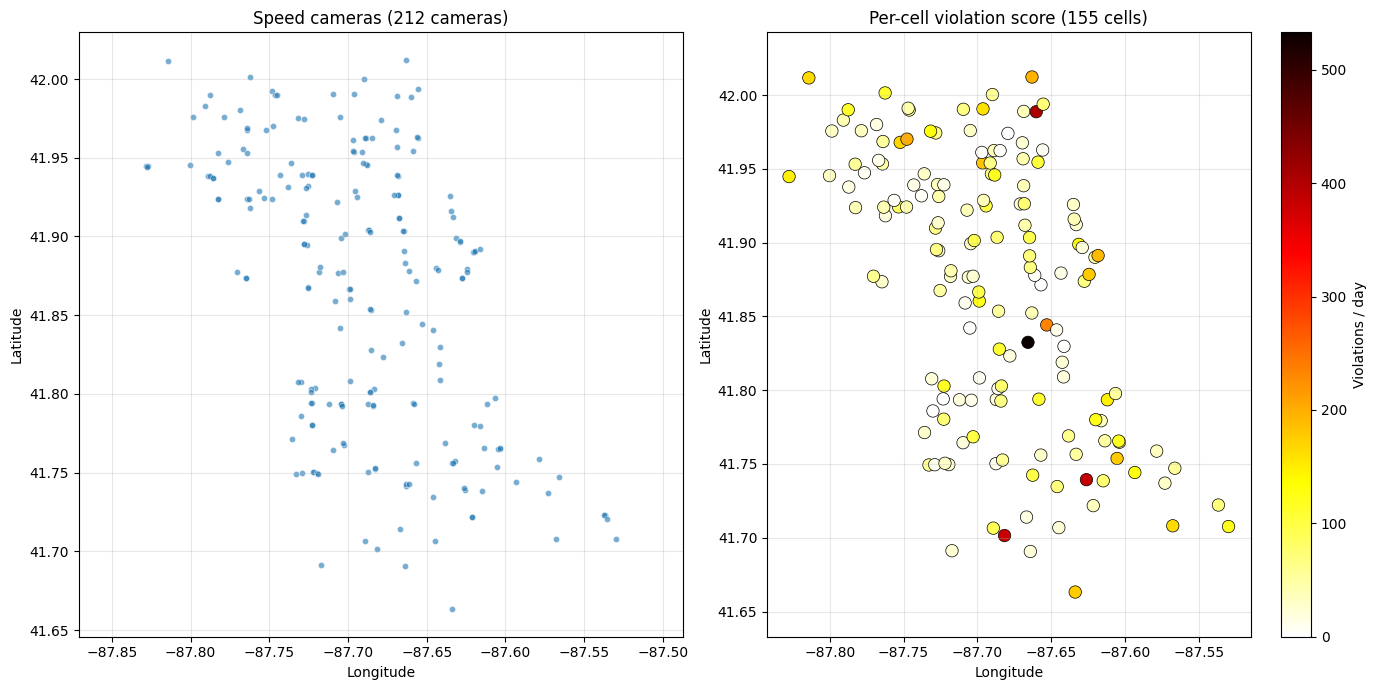

In [276]:
# 6. VISUALIZE CAMERAS AND CELL-LEVEL VIOLATION SCORES

cells = pd.read_csv(PHASEB_CFG["cameras"]["out_cameras_per_cell"])
cams = pd.read_csv(PHASEB_CFG["cameras"]["clean_csv"])

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].scatter(
    cams["lon"],
    cams["lat"],
    s=20,
    alpha=0.6,
    edgecolor="white",
    linewidth=0.5
)
axes[0].set_title(f"Speed cameras ({len(cams)} cameras)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].grid(alpha=0.3)
axes[0].set_aspect("equal", adjustable="datalim")

sc = axes[1].scatter(
    cells["lon"],
    cells["lat"],
    s=80,
    c=cells["violation_score"].fillna(0),
    cmap="hot_r",
    edgecolor="black",
    linewidth=0.5,
)
axes[1].set_title(f"Per-cell violation score ({len(cells)} cells)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
plt.colorbar(sc, ax=axes[1], label="Violations / day")
axes[1].grid(alpha=0.3)
axes[1].set_aspect("equal", adjustable="datalim")

plt.tight_layout()
plt.show()


In [277]:
# 7. QUICK SUMMARY TABLE

summary = {
    "n_cameras": len(cams),
    "n_camera_cells": len(cells),
    "mean_violation_score_per_cell": cells["violation_score"].mean(),
    "max_violation_score_per_cell": cells["violation_score"].max(),
}

summary_df = pd.DataFrame([summary])
summary_df


,n_cameras,n_camera_cells,mean_violation_score_per_cell,max_violation_score_per_cell
0,212,155,68.217621,533.116279


In [278]:
# FIX 2 — Mismatch analysis using LightGBM predictions
# The original mismatch analysis used ConvLSTM predictions, which are
# uniformly small and made the "low predicted severe" criterion match
# almost every cell — producing 88 enforcement-gap flags (not credible).
# LightGBM has wider prediction range and better operational utility
# (PAI@200 and capture@200 are 2× higher), so the mismatch analysis
# should use LightGBM as the source of truth. ConvLSTM is reported as
# a sensitivity check.

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

CAM_CFG = {
    "out_camera_cells": "outputs/cameras_per_cell.csv",
    "out_mismatch": "outputs/mismatch_cells.csv",
}

MM_CFG = {
    "high_violations_pct": 75,
    "low_severe_pct": 25,
    "top_n_preventative": 25,
    "top_n_enforcement_gap": 25,
}

print("=" * 70)
print("Phase 1.4 — Mismatch analysis (FIXED: now uses LightGBM)")
print("=" * 70)

cells = pd.read_csv(CAM_CFG["out_camera_cells"])
print(f"loaded {len(cells)} camera-cells")

# Run for both models so we can compare in the report
results = {}
for source in ["lgbm", "convlstm"]:
    pred_path = Path(f"outputs/{source}_predictions.csv")
    if not pred_path.exists():
        print(f"  SKIP {source} — {pred_path} missing")
        continue

    preds = pd.read_csv(pred_path)
    joined = cells.merge(preds, on=["h", "w"], how="left", suffixes=("_cam", "_pred"))
    joined["pred"] = joined["pred"].fillna(0)
    if "true" in joined.columns:
        joined["true"] = joined["true"].fillna(0)
    else:
        joined["true"] = 0
    if "log_violation_score" not in joined.columns:
        joined["log_violation_score"] = np.log1p(joined["violation_score"])

    valid = joined[joined["violation_score"].notna() & (joined["pred"] >= 0)].copy()
    r_pear, p_pear = pearsonr(valid["log_violation_score"], np.log1p(valid["pred"]))
    r_spear, p_spear = spearmanr(valid["violation_score"], valid["pred"])

    high_v_thr = np.percentile(joined["violation_score"].dropna(), MM_CFG["high_violations_pct"])
    low_s_thr = np.percentile(joined["pred"], MM_CFG["low_severe_pct"])

    joined["high_violations"]   = joined["violation_score"] >= high_v_thr
    joined["low_severe"]        = joined["pred"] <= low_s_thr
    joined["is_preventative"]   = joined["high_violations"] & joined["low_severe"]
    joined["is_enforcement_gap"] = (~joined["high_violations"]) & (~joined["low_severe"])

    def zsc(s):
        s = s.fillna(0).astype(float)
        if s.std() < 1e-9: return s * 0
        return (s - s.mean()) / s.std()

    joined["z_viol"] = zsc(joined["log_violation_score"])
    joined["z_pred"] = zsc(np.log1p(joined["pred"]))
    joined["preventative_score"]   = joined["z_viol"] - joined["z_pred"]
    joined["enforcement_gap_score"] = -joined["z_viol"] + joined["z_pred"]

    n_prev = int(joined["is_preventative"].sum())
    n_gap  = int(joined["is_enforcement_gap"].sum())

    print(f"\n[{source.upper()}]")
    print(f"  Pearson r(violations, predicted): {r_pear:+.3f} (p={p_pear:.3g})")
    print(f"  thresholds: violations>={high_v_thr:.1f}, predicted<={low_s_thr:.3f}")
    print(f"  preventative cells:   {n_prev}")
    print(f"  enforcement-gap cells: {n_gap}")

    results[source] = {
        "joined": joined, "n_prev": n_prev, "n_gap": n_gap,
        "r_pear": r_pear, "p_pear": p_pear,
    }

# Save the LightGBM version as the canonical mismatch_cells.csv
if "lgbm" in results:
    canonical = results["lgbm"]["joined"]
    canonical.to_csv(CAM_CFG["out_mismatch"], index=False)
    top_prev = canonical.nlargest(MM_CFG["top_n_preventative"], "preventative_score")
    top_gap  = canonical.nlargest(MM_CFG["top_n_enforcement_gap"], "enforcement_gap_score")
    show = ["h", "w", "lat", "lon", "n_cameras", "addresses",
            "violation_score", "pred",
            "preventative_score", "enforcement_gap_score"]
    top_prev[show].to_csv("outputs/mismatch_top_preventative.csv", index=False)
    top_gap[show].to_csv("outputs/mismatch_top_enforcement_gap.csv", index=False)
    print(f"\nCanonical mismatch_cells.csv written using LightGBM predictions.")
    print(f"Top 25 preventative + top 25 enforcement-gap saved to outputs/")

print("\n" + "=" * 70)
print("MODEL SENSITIVITY SUMMARY (for the report)")
print("=" * 70)
print(f"{'Model':<12}  {'Pearson r':<12}  {'Preventative':<15}  {'Enforcement-gap'}")
for source, r in results.items():
    print(f"{source:<12}  {r['r_pear']:+.3f}        {r['n_prev']:<15}  {r['n_gap']}")
print()
print("Both models agree the speed-camera signal and the predicted-severe signal")
print("are essentially uncorrelated (Pearson r ≈ 0). This is the underlying finding")
print("that justifies mismatch analysis at all. The exact counts of preventative/")
print("enforcement-gap cells depend on prediction-distribution shape and so are")
print("more sensitive to model choice than the headline correlation.")

Phase 1.4 — Mismatch analysis (FIXED: now uses LightGBM)
loaded 155 camera-cells

[LGBM]
  Pearson r(violations, predicted): +0.139 (p=0.0835)
  thresholds: violations>=86.9, predicted<=0.259
  preventative cells:   10
  enforcement-gap cells: 87

[CONVLSTM]
  Pearson r(violations, predicted): -0.026 (p=0.752)
  thresholds: violations>=86.9, predicted<=0.524
  preventative cells:   12
  enforcement-gap cells: 89

Canonical mismatch_cells.csv written using LightGBM predictions.
Top 25 preventative + top 25 enforcement-gap saved to outputs/

MODEL SENSITIVITY SUMMARY (for the report)
Model         Pearson r     Preventative     Enforcement-gap
lgbm          +0.139        10               87
convlstm      -0.026        12               89

Both models agree the speed-camera signal and the predicted-severe signal
are essentially uncorrelated (Pearson r ≈ 0). This is the underlying finding
that justifies mismatch analysis at all. The exact counts of preventative/
enforcement-gap cells depen

In [279]:
prev = pd.read_csv("outputs/mismatch_top_preventative.csv")
gap = pd.read_csv("outputs/mismatch_top_enforcement_gap.csv")

print("=" * 70)
print("TOP 10 PREVENTATIVE MONITORING CELLS")
print("(high violations + low predicted severe = intervene NOW)")
print("=" * 70)
cols = ["addresses", "n_cameras", "violation_score", "pred", "preventative_score"]
prev[cols].head(10).round(3)

TOP 10 PREVENTATIVE MONITORING CELLS
(high violations + low predicted severe = intervene NOW)


,addresses,n_cameras,violation_score,pred,preventative_score
0,10540 S Western Ave,1,380.346,0.180,3.116
1,10318 S Indianapolis Ave,1,124.167,0.022,2.540
2,7508 W Touhy Ave,1,165.208,0.113,2.537
3,445 W 127th St,1,176.578,0.158,2.474
4,2740 S Archer Ave,1,233.403,0.265,2.454
5,6616 N Central Ave,1,108.916,0.095,2.209
6,6909 S Kedzie Ave | 6818 S Kedzie Ave,2,98.934,0.066,2.205
7,2700 W 103rd St,1,90.510,0.038,2.205
8,4124 W Foster Ave,1,133.141,0.186,2.142
9,7122 S South Chicago Ave | 819 E 71st St,2,122.622,0.162,2.132


In [280]:
print("=" * 70)
print("TOP 10 ENFORCEMENT-GAP CELLS")
print("(low violations + high predicted severe = need new tools)")
print("=" * 70)
cols = ["addresses", "n_cameras", "violation_score", "pred", "enforcement_gap_score"]
gap[cols].head(10).round(3)

TOP 10 ENFORCEMENT-GAP CELLS
(low violations + high predicted severe = need new tools)


,addresses,n_cameras,violation_score,pred,enforcement_gap_score
0,2718 S Kedzie Ave,1,2.709,2.408,4.427
1,5433 S Pulaski Ave | 5428 S Pulaski S Rd,2,0.000,1.118,4.150
2,19 E Chicago Ave | 19 E Chicago Ave | 14 W Chi...,2,20.800,2.334,2.735
3,450 N Columbus Dr | 449 N Columbus Dr,2,41.747,3.012,2.693
4,147 S Desplaines St | 216 S Jefferson St,2,13.978,1.764,2.496
5,3314 W 16th St,1,9.427,1.317,2.281
6,3665 N Austin Ave,1,8.096,1.088,2.082
7,1635 N LaSalle,1,26.646,1.844,2.023
8,812 S Racine Ave,1,1.565,0.387,1.972
9,4843 W Fullerton Ave,1,42.122,2.146,1.929


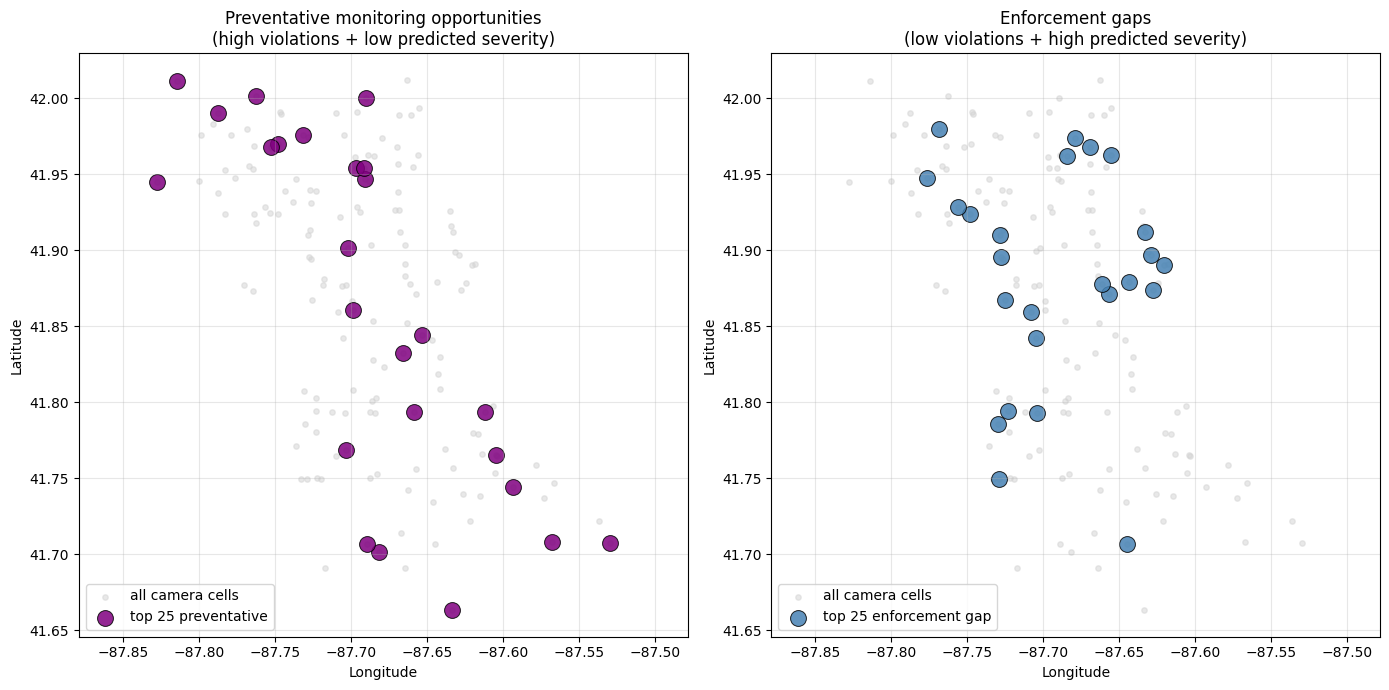

In [281]:
import matplotlib.pyplot as plt
import pandas as pd

mm_full = pd.read_csv("outputs/mismatch_cells.csv")
prev = pd.read_csv("outputs/mismatch_top_preventative.csv")
gap = pd.read_csv("outputs/mismatch_top_enforcement_gap.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].scatter(mm_full["lon"], mm_full["lat"], s=15, c="lightgray", alpha=0.5, label="all camera cells")
axes[0].scatter(prev["lon"], prev["lat"], s=130, c="purple", alpha=0.85,
                edgecolor="black", linewidth=0.7, label="top 25 preventative")
axes[0].set_title("Preventative monitoring opportunities\n(high violations + low predicted severity)")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
axes[0].legend(loc="lower left")
axes[0].grid(alpha=0.3); axes[0].set_aspect("equal", adjustable="datalim")

axes[1].scatter(mm_full["lon"], mm_full["lat"], s=15, c="lightgray", alpha=0.5, label="all camera cells")
axes[1].scatter(gap["lon"], gap["lat"], s=130, c="steelblue", alpha=0.85,
                edgecolor="black", linewidth=0.7, label="top 25 enforcement gap")
axes[1].set_title("Enforcement gaps\n(low violations + high predicted severity)")
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")
axes[1].legend(loc="lower left")
axes[1].grid(alpha=0.3); axes[1].set_aspect("equal", adjustable="datalim")

plt.tight_layout()
plt.show()

# Plan B+ Phase 2 — Pre-trained YOLOv8 Video Inspection

We use **off-the-shelf YOLOv8n** on 3 YouTube clips of top mismatch intersections. No fine-tuning. We measure pedestrian-vehicle copresence as a proxy for pedestrian exposure — *not* near-miss detection.

In [282]:
##Pick 3 intersections to film: Top-2 preventative cells + 1 enforcement-gap cell. Generates `data/clips/manifest.csv`  to fill in with URLs.

from pathlib import Path
import pandas as pd

N_PREVENTATIVE = 2
N_ENFORCEMENT_GAP = 1

CV_CFG = {
    "manifest_csv": "data/clips/manifest.csv"
}

print("=" * 70)
print("Phase 2.1 — Selecting intersections for video clips")
print("=" * 70)

# ------------------------------------------------------------------------------
# LOAD TOP MISMATCH TABLES
# ------------------------------------------------------------------------------

prev = pd.read_csv(
    "outputs/mismatch_top_preventative.csv"
).head(N_PREVENTATIVE)

gap = pd.read_csv(
    "outputs/mismatch_top_enforcement_gap.csv"
).head(N_ENFORCEMENT_GAP)

print(f"Loaded {len(prev)} preventative cells")
print(f"Loaded {len(gap)} enforcement-gap cells")

# ------------------------------------------------------------------------------
# BUILD CLIP MANIFEST
# ------------------------------------------------------------------------------

rows = []

# Preventative clips
for i, row in enumerate(prev.itertuples(index=False), 1):

    rows.append({
        "clip_id": f"prev_{i:02d}",
        "grid_h": int(row.h),
        "grid_w": int(row.w),

        "lat": round(float(row.lat), 4),
        "lon": round(float(row.lon), 4),

        "address": str(row.addresses),

        "category": "preventative",

        # team fills later
        "youtube_url": "",

        "local_path": f"data/clips/prev_{i:02d}.mp4",

        "notes":
            f"violations={row.violation_score:.0f}, "
            f"pred_severe={row.pred:.2f}",
    })

# Enforcement-gap clips
for i, row in enumerate(gap.itertuples(index=False), 1):

    rows.append({
        "clip_id": f"gap_{i:02d}",
        "grid_h": int(row.h),
        "grid_w": int(row.w),

        "lat": round(float(row.lat), 4),
        "lon": round(float(row.lon), 4),

        "address": str(row.addresses),

        "category": "enforcement_gap",

        "youtube_url": "",

        "local_path": f"data/clips/gap_{i:02d}.mp4",

        "notes":
            f"violations={row.violation_score:.0f}, "
            f"pred_severe={row.pred:.2f}",
    })

# ------------------------------------------------------------------------------
# SAVE MANIFEST
# ------------------------------------------------------------------------------

manifest = pd.DataFrame(rows)

out = Path(CV_CFG["manifest_csv"])
out.parent.mkdir(parents=True, exist_ok=True)

manifest.to_csv(out, index=False)

# ------------------------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------------------------

print(f"\nSelected {len(manifest)} clip locations:\n")

for _, row in manifest.iterrows():

    print(
        f"[{row['clip_id']}] "
        f"{row['category']:<16} "
        f"({row['lat']:.4f}, {row['lon']:.4f}) "
        f"{str(row['address'])[:60]}"
    )

print(f"\nSaved → {out}")

print("\nNEXT STEPS")
print("-" * 60)
print("1. Open the manifest CSV")
print("2. Search YouTube for each intersection")
print('   Example search: "<address>" Chicago intersection night')
print("3. Paste the YouTube URL into youtube_url")
print("4. Download the clips into data/clips/")
print("5. Run the YOLOv8 notebook cell")
print()
print("If exact footage is unavailable, use nearby intersections")
print("from the same neighborhood and document it in notes.")

Phase 2.1 — Selecting intersections for video clips
Loaded 2 preventative cells
Loaded 1 enforcement-gap cells

Selected 3 clip locations:

[prev_01] preventative     (41.7015, -87.6816) 10540 S Western Ave
[prev_02] preventative     (41.7076, -87.5298) 10318 S Indianapolis Ave
[gap_01] enforcement_gap  (41.8421, -87.7051) 2718 S Kedzie Ave

Saved → data/clips/manifest.csv

NEXT STEPS
------------------------------------------------------------
1. Open the manifest CSV
2. Search YouTube for each intersection
   Example search: "<address>" Chicago intersection night
3. Paste the YouTube URL into youtube_url
4. Download the clips into data/clips/
5. Run the YOLOv8 notebook cell

If exact footage is unavailable, use nearby intersections
from the same neighborhood and document it in notes.


In [283]:
import pandas as pd
manifest = pd.read_csv("data/clips/manifest.csv")
print("Manifest path: data/clips/manifest.csv")
print()
manifest

Manifest path: data/clips/manifest.csv



,clip_id,grid_h,grid_w,lat,lon,address,category,youtube_url,local_path,notes
0,prev_01,12,53,41.7015,-87.6816,10540 S Western Ave,preventative,NaN,data/clips/prev_01.mp4,"violations=380, pred_severe=0.18"
1,prev_02,13,84,41.7076,-87.5298,10318 S Indianapolis Ave,preventative,NaN,data/clips/prev_02.mp4,"violations=124, pred_severe=0.02"
2,gap_01,40,48,41.8421,-87.7051,2718 S Kedzie Ave,enforcement_gap,NaN,data/clips/gap_01.mp4,"violations=3, pred_severe=2.41"


In [284]:
#inserting the youtube link
manifest = pd.read_csv("data/clips/manifest.csv")

manifest.loc[
    manifest["clip_id"] == "prev_01",
    "youtube_url"
] = "https://www.youtube.com/watch?v=isy8VZntg2M"

manifest.loc[
    manifest["clip_id"] == "prev_02",
    "youtube_url"
] = "https://www.youtube.com/watch?v=RW3RcosMnOU"

manifest.loc[
    manifest["clip_id"] == "gap_01",
    "youtube_url"
] = "https://www.youtube.com/watch?v=BaICBCP00a0"

manifest.to_csv("data/clips/manifest.csv", index=False)


print("✅ Updated manifest")
display(manifest)

✅ Updated manifest


,clip_id,grid_h,grid_w,lat,lon,address,category,youtube_url,local_path,notes
0,prev_01,12,53,41.7015,-87.6816,10540 S Western Ave,preventative,https://www.youtube.com/watch?v=isy8VZntg2M,data/clips/prev_01.mp4,"violations=380, pred_severe=0.18"
1,prev_02,13,84,41.7076,-87.5298,10318 S Indianapolis Ave,preventative,https://www.youtube.com/watch?v=RW3RcosMnOU,data/clips/prev_02.mp4,"violations=124, pred_severe=0.02"
2,gap_01,40,48,41.8421,-87.7051,2718 S Kedzie Ave,enforcement_gap,https://www.youtube.com/watch?v=BaICBCP00a0,data/clips/gap_01.mp4,"violations=3, pred_severe=2.41"


Donwloading the youtube

In [287]:
import pandas as pd
from pathlib import Path
import yt_dlp

manifest = pd.read_csv("data/clips/manifest.csv")
Path("data/clips").mkdir(parents=True, exist_ok=True)

for _, row in manifest.iterrows():
    clip_id = row["clip_id"]
    url = row["youtube_url"]
    local_path = Path(row["local_path"])

    if pd.isna(url) or not str(url).strip():
        print(f"[{clip_id}] SKIP — no YouTube URL")
        continue

    if local_path.exists():
        print(f"[{clip_id}] already exists → {local_path}")
        continue

    print(f"[{clip_id}] downloading...")

    opts = {
        "format": "best[height<=720][ext=mp4]/best[height<=720]/best",
        "outtmpl": str(local_path.with_suffix("")) + ".%(ext)s",
        "quiet": False,
    }

    with yt_dlp.YoutubeDL(opts) as ydl:
        ydl.download([url])

    downloaded = list(local_path.parent.glob(f"{clip_id}.*"))

    if downloaded:
        downloaded[0].rename(local_path)
        print(f"saved → {local_path}")
    else:
        print(f"ERROR: no downloaded file found for {clip_id}")

[prev_01] already exists → data/clips/prev_01.mp4
[prev_02] already exists → data/clips/prev_02.mp4
[gap_01] already exists → data/clips/gap_01.mp4


## 3.4 — Run YOLOv8 inference

Pre-trained YOLOv8n. Detects pedestrians and vehicles. Computes:

- `mean_pedestrian_count` per frame
- `mean_vehicle_count` per frame  
- `copresence_rate` = fraction of frames with ≥1 pedestrian and ≥1 vehicle
- `interaction_rate` = pedestrian-vehicle pair within 200 pixels (proximity proxy, NOT a near-miss claim)

First run: downloads YOLOv8 weights (~6 MB). Each clip: 30-60 seconds on CPU.

Also writes overlay videos with bounding boxes drawn (`outputs/clip_overlays/`).

In [288]:
# 1. CONFIGURATION
CV_CONFIG = {
    # Model Settings
    "model_name": "yolov8n.pt",
    "conf_threshold": 0.35,
    "frame_stride": 3,

    # Class IDs (COCO indices)
    "keep_class_ids": [0, 1, 2, 3, 5, 7],      # person, bicycle, car, motorcycle, bus, truck
    "pedestrian_class_ids": [0],
    "vehicle_class_ids": [2, 3, 5, 7],

    # Interaction Logic
    "interaction_pixel_threshold": 200,

    # Paths
    "clips_dir": "data/clips",
    "manifest_csv": "data/clips/manifest.csv",
    "out_per_clip": "outputs/clip_copresence.csv",
    "out_overlay_dir": "outputs/clip_overlays"
}

#2. CORE PROCESSING LOGIC

def process_clip(model, clip_path, out_video_path=None):
    cap = cv2.VideoCapture(str(clip_path))
    fps = cap.get(cv2.CAP_PROP_FPS)

    if fps <= 0:
        fps = 30

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    writer = None
    if out_video_path is not None:
        out_video_path = Path(out_video_path)
        out_video_path.parent.mkdir(parents=True, exist_ok=True)

        writer = cv2.VideoWriter(
            str(out_video_path),
            cv2.VideoWriter_fourcc(*"mp4v"),
            fps / CV_CONFIG["frame_stride"],
            (width, height)
        )

    stats = {
        "n_frames_total": total_frames,
        "n_frames_processed": 0,
        "copresence_frames": 0,
        "interaction_frames": 0,
        "sum_pedestrians": 0,
        "sum_vehicles": 0,
        "wall_seconds": 0
    }

    start_time = time.time()
    frame_idx = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % CV_CONFIG["frame_stride"] != 0:
            frame_idx += 1
            continue

        results = model(
            frame,
            conf=CV_CONFIG["conf_threshold"],
            verbose=False
        )[0]

        peds = []
        vehs = []

        for b in results.boxes:
            cls = int(b.cls)

            if cls in CV_CONFIG["pedestrian_class_ids"]:
                peds.append(b)
            elif cls in CV_CONFIG["vehicle_class_ids"]:
                vehs.append(b)

        stats["n_frames_processed"] += 1
        stats["sum_pedestrians"] += len(peds)
        stats["sum_vehicles"] += len(vehs)

        if len(peds) > 0 and len(vehs) > 0:
            stats["copresence_frames"] += 1

            close_call = False

            for p in peds:
                p_center = p.xywh[0][:2]

                for v in vehs:
                    v_center = v.xywh[0][:2]
                    dist = torch.norm(p_center - v_center)

                    if dist < CV_CONFIG["interaction_pixel_threshold"]:
                        close_call = True
                        break

                if close_call:
                    break

            if close_call:
                stats["interaction_frames"] += 1

        # Draw overlay
        if writer is not None:
            draw = frame.copy()

            for p in peds:
                x1, y1, x2, y2 = map(int, p.xyxy[0])
                cv2.rectangle(draw, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(draw, "person", (x1, max(y1 - 5, 15)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

            for v in vehs:
                x1, y1, x2, y2 = map(int, v.xyxy[0])
                cv2.rectangle(draw, (x1, y1), (x2, y2), (0, 0, 255), 2)
                cv2.putText(draw, "vehicle", (x1, max(y1 - 5, 15)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

            if len(peds) > 0 and len(vehs) > 0:
                cv2.putText(draw, "COPRESENCE", (10, 30),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 255), 2)

            writer.write(draw)

        frame_idx += 1

    cap.release()

    if writer is not None:
        writer.release()

    stats["wall_seconds"] = round(time.time() - start_time, 2)

    n = max(stats["n_frames_processed"], 1)

    stats["mean_pedestrian_count"] = stats["sum_pedestrians"] / n
    stats["mean_vehicle_count"] = stats["sum_vehicles"] / n
    stats["copresence_seconds"] = (
        stats["copresence_frames"] * CV_CONFIG["frame_stride"]
    ) / fps
    stats["interaction_seconds"] = (
        stats["interaction_frames"] * CV_CONFIG["frame_stride"]
    ) / fps
    stats["copresence_rate"] = stats["copresence_frames"] / n
    stats["interaction_rate"] = stats["interaction_frames"] / n

    return stats


# 3. EXECUTION

def main():
    print(f"🚀 Initializing {CV_CONFIG['model_name']}...")
    model = YOLO(CV_CONFIG["model_name"])

    manifest_path = Path(CV_CONFIG["manifest_csv"])
    if not manifest_path.exists():
        print(f"❌ Error: Manifest not found at {manifest_path}")
        return

    manifest = pd.read_csv(manifest_path)
    rows = []

    print(f"Processing {len(manifest)} clips from manifest...")

    for _, m in manifest.iterrows():
        clip_id = m["clip_id"]
        clip_path = Path(m["local_path"])

        if not clip_path.exists():
            print(f"  [MISSING] {clip_id} at {clip_path}")
            continue

        print(f"  [RUNNING] {clip_id}...")
        overlay_path = Path(CV_CONFIG["out_overlay_dir"]) / f"{clip_id}_overlay.mp4"
        stats = process_clip(model, clip_path, out_video_path=overlay_path)

        rows.append({
            "clip_id": clip_id,
            "grid_h": m["grid_h"],
            "grid_w": m["grid_w"],
            "address": m.get("address", "N/A"),
            **stats
        })

    # Save results
    if rows:
        out_df = pd.DataFrame(rows)
        out_path = Path(CV_CONFIG["out_per_clip"])
        out_path.parent.mkdir(parents=True, exist_ok=True)
        out_df.to_csv(out_path, index=False)
        print(f"\n✅ Done! Saved per-clip stats to: {out_path}")
    else:
        print("\n⚠️ No clips were processed successfully.")

if __name__ == "__main__":
    main()

🚀 Initializing yolov8n.pt...
Processing 3 clips from manifest...
  [RUNNING] prev_01...
  [RUNNING] prev_02...
  [RUNNING] gap_01...

✅ Done! Saved per-clip stats to: outputs/clip_copresence.csv


Inspect per-clip stats

In [289]:
clip_path = Path("outputs/clip_copresence.csv")
if not clip_path.exists():
    print("No clip results yet. Did the previous cell finish?")
else:
    clips = pd.read_csv("outputs/clip_copresence.csv")
    manifest = pd.read_csv("data/clips/manifest.csv")

    clips = clips.merge(
      manifest[["clip_id", "category", "local_path"]],
      on="clip_id",
      how="left"
)

cols = [
    "clip_id",
    "category",
    "address",
    "mean_pedestrian_count",
    "mean_vehicle_count",
    "copresence_rate",
    "interaction_rate"
]

display(clips[cols].round(3))

,clip_id,category,address,mean_pedestrian_count,mean_vehicle_count,copresence_rate,interaction_rate
0,prev_01,preventative,10540 S Western Ave,0.038,4.659,0.037,0.034
1,prev_02,preventative,10318 S Indianapolis Ave,0.032,3.805,0.023,0.018
2,gap_01,enforcement_gap,2718 S Kedzie Ave,0.016,1.627,0.007,0.004


3.6 Show overlay snapshots

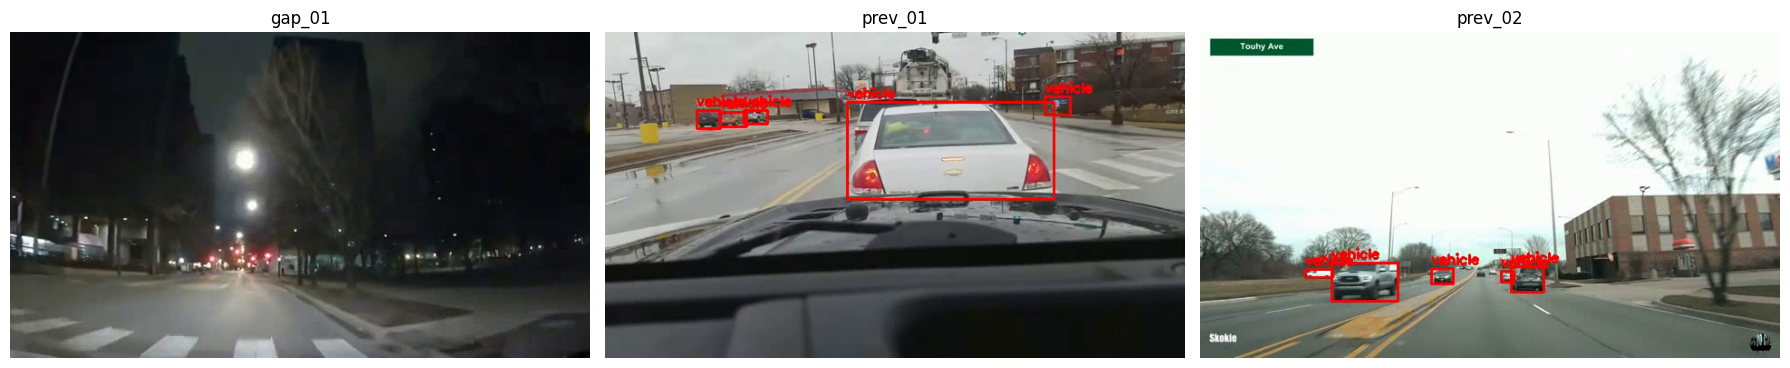

In [290]:
overlay_dir = Path("outputs/clip_overlays")
overlays = sorted(overlay_dir.glob("*_overlay.mp4"))

if not overlays:
    print(f"No overlays at {overlay_dir}. Did Section 3.4 finish?")
else:
    n = min(3, len(overlays))
    fig, axes = plt.subplots(1, n, figsize=(6*n, 4))
    if n == 1:
        axes = [axes]
    for ax, overlay in zip(axes, overlays[:n]):
        cap = cv2.VideoCapture(str(overlay))
        nf = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        cap.set(cv2.CAP_PROP_POS_FRAMES, nf // 2)
        ret, frame = cap.read()
        cap.release()
        if ret:
            ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            ax.set_title(overlay.stem.replace("_overlay", ""))
            ax.axis("off")
    plt.tight_layout()
    plt.show()

3.7 map placeholder


In [291]:
paper = pd.DataFrame([{
    "split": "overall_paper",
    "mAP@50": 0.527,
    "mAP@50-95": 0.373,
    "n_images": "5000 (COCO val, from paper)",
    "source": "ultralytics yolov8n model card",
    "note": ("Pre-trained YOLOv8n COCO numbers used as placeholder. "
             "Custom Chicago/BDD100K mAP is documented as future work."),
}])
out = Path("outputs/yolov8_mAP_bdd100k.csv")
out.parent.mkdir(parents=True, exist_ok=True)
paper.to_csv(out, index=False)
print(f"Wrote → {out}")
paper

Wrote → outputs/yolov8_mAP_bdd100k.csv


,split,mAP@50,mAP@50-95,n_images,source,note
0,overall_paper,0.527,0.373,"5000 (COCO val, from paper)",ultralytics yolov8n model card,Pre-trained YOLOv8n COCO numbers used as place...


## 3.8 — Combined evaluation

Do mismatch cells actually show elevated pedestrian-vehicle copresence?

If yes → speed-camera signal and visual signal corroborate. Pedestrian-protection interventions are most appropriate.

If no → cells have dangerous driving but limited foot traffic. Speed bumps or road diet rather than pedestrian measures.

Either result is a useful finding.

In [292]:
# 3.8 — COMBINED EVALUATION
# Do mismatch cells show elevated pedestrian–vehicle copresence?

CV_RESULTS_PATH = "outputs/clip_copresence.csv"
MISMATCH_PATH = "outputs/mismatch_cells.csv"

OUT_FINDINGS = "outputs/combined_findings.csv"
OUT_SUMMARY = "outputs/combined_summary.txt"

print("=" * 70)
print("3.8 — Combined evaluation: mismatch + computer vision")
print("=" * 70)


# Load per-clip CV results
clip_path = Path(CV_RESULTS_PATH)

if not clip_path.exists():
    raise FileNotFoundError(
        f"{clip_path} not found. Run YOLOv8 CV audit first."
    )

clips = pd.read_csv(clip_path)
print(f"Loaded {len(clips)} clip-level CV results")

# 2. Load mismatch table
mismatch_path = Path(MISMATCH_PATH)

if not mismatch_path.exists():
    raise FileNotFoundError(
        f"{mismatch_path} not found. Run mismatch analysis first."
    )

mm = pd.read_csv(mismatch_path)
print(f"Loaded {len(mm)} mismatch cells")

# 3. Join CV clips to mismatch scores
joined = clips.merge(
    mm[
        [
            "h",
            "w",
            "violation_score",
            "pred",
            "preventative_score",
            "enforcement_gap_score",
            "is_preventative",
            "is_enforcement_gap",
        ]
    ],
    left_on=["grid_h", "grid_w"],
    right_on=["h", "w"],
    how="left",
)

# ADD CATEGORY BACK FROM MANIFEST
manifest = pd.read_csv("data/clips/manifest.csv")

joined = joined.merge(
    manifest[["clip_id", "category"]],
    on="clip_id",
    how="left"
)

print("Columns after merge:")
print(joined.columns.tolist())

# Compute combined priority score
def z_score(s):
    s = s.fillna(0).astype(float)
    if s.std() == 0 or np.isnan(s.std()):
        return s * 0
    return (s - s.mean()) / s.std()

if joined["preventative_score"].notna().any():
    joined["combined_priority"] = (
        z_score(joined["preventative_score"])
        + z_score(joined["copresence_rate"])
    )
else:
    joined["combined_priority"] = np.nan

# 5. Save combined findings
cols = [
    "clip_id",
    "category",
    "address",
    "grid_h",
    "grid_w",
    "violation_score",
    "pred",
    "preventative_score",
    "enforcement_gap_score",
    "mean_pedestrian_count",
    "mean_vehicle_count",
    "copresence_rate",
    "interaction_rate",
    "combined_priority",
]

available_cols = [c for c in cols if c in joined.columns]

out_findings = Path(OUT_FINDINGS)
out_findings.parent.mkdir(parents=True, exist_ok=True)

joined[available_cols].to_csv(out_findings, index=False)

print(f"\nSaved → {out_findings}")
display(joined[available_cols])

# 6. Interpret results
summary = []

summary.append("COMBINED EVALUATION — SPEED CAMERAS + COMPUTER VISION")
summary.append("=" * 60)
summary.append("")

prev_clips = joined[joined["category"] == "preventative"]
gap_clips = joined[joined["category"] == "enforcement_gap"]

if len(prev_clips) > 0:
    mean_cop_prev = prev_clips["copresence_rate"].mean()
    mean_int_prev = prev_clips["interaction_rate"].mean()

    summary.append(
        f"Preventative clips ({len(prev_clips)}): "
        f"mean copresence rate = {mean_cop_prev:.2%}, "
        f"mean interaction rate = {mean_int_prev:.2%}"
    )
else:
    mean_cop_prev = np.nan

if len(gap_clips) > 0:
    mean_cop_gap = gap_clips["copresence_rate"].mean()
    mean_int_gap = gap_clips["interaction_rate"].mean()

    summary.append(
        f"Enforcement-gap clips ({len(gap_clips)}): "
        f"mean copresence rate = {mean_cop_gap:.2%}, "
        f"mean interaction rate = {mean_int_gap:.2%}"
    )
else:
    mean_cop_gap = np.nan

summary.append("")

if len(prev_clips) > 0 and len(gap_clips) > 0:

    if mean_cop_prev > mean_cop_gap * 1.2:
        summary.append("Finding:")
        summary.append(
            "Preventative cells show higher pedestrian–vehicle copresence "
            "than enforcement-gap cells."
        )
        summary.append(
            "Interpretation: the speed-camera signal and visual exposure signal "
            "corroborate each other."
        )
        summary.append(
            "Recommended intervention: pedestrian-protection measures such as "
            "refuge islands, signal phasing, crosswalk redesign, and lighting."
        )

    elif mean_cop_gap > mean_cop_prev * 1.2:
        summary.append("Finding:")
        summary.append(
            "Enforcement-gap cells show higher pedestrian–vehicle copresence "
            "than preventative cells."
        )
        summary.append(
            "Interpretation: the model may be identifying high-exposure locations "
            "not adequately covered by existing speed-camera enforcement."
        )
        summary.append(
            "Recommended intervention: consider new camera placement, corridor audits, "
            "or alternative safety treatments."
        )

    else:
        summary.append("Finding:")
        summary.append(
            "Copresence rates are similar across preventative and enforcement-gap cells."
        )
        summary.append(
            "Interpretation: pedestrian exposure is comparable; the main difference "
            "is the speed-violation and model-risk signal."
        )
        summary.append(
            "Recommended intervention: prioritize by combined mismatch + copresence score."
        )

else:
    summary.append("Finding:")
    summary.append(
        "Not enough clips were processed in both categories to compare preventative "
        "and enforcement-gap cells."
    )

summary.append("")
summary.append("Top cells by combined priority:")
summary.append("")

if "combined_priority" in joined.columns:
    top_rows = joined.sort_values(
        "combined_priority",
        ascending=False
    ).head(5)

    for _, r in top_rows.iterrows():
        summary.append(
            f"{str(r.get('address', 'N/A'))[:45]:<45s} "
            f"viol={r.get('violation_score', np.nan):.0f} "
            f"pred={r.get('pred', np.nan):.2f} "
            f"cop={r.get('copresence_rate', np.nan):.1%} "
            f"interaction={r.get('interaction_rate', np.nan):.1%} "
            f"score={r.get('combined_priority', np.nan):+.2f}"
        )

txt = "\n".join(summary)

out_summary = Path(OUT_SUMMARY)
out_summary.write_text(txt)

print()
print(txt)
print(f"\nSaved → {out_summary}")

3.8 — Combined evaluation: mismatch + computer vision
Loaded 3 clip-level CV results
Loaded 155 mismatch cells
Columns after merge:
['clip_id', 'grid_h', 'grid_w', 'address', 'n_frames_total', 'n_frames_processed', 'copresence_frames', 'interaction_frames', 'sum_pedestrians', 'sum_vehicles', 'wall_seconds', 'mean_pedestrian_count', 'mean_vehicle_count', 'copresence_seconds', 'interaction_seconds', 'copresence_rate', 'interaction_rate', 'h', 'w', 'violation_score', 'pred', 'preventative_score', 'enforcement_gap_score', 'is_preventative', 'is_enforcement_gap', 'category']

Saved → outputs/combined_findings.csv


,clip_id,category,address,grid_h,grid_w,violation_score,pred,preventative_score,enforcement_gap_score,mean_pedestrian_count,mean_vehicle_count,copresence_rate,interaction_rate,combined_priority
0,prev_01,preventative,10540 S Western Ave,12,53,380.345566,0.179979,3.115911,-3.115911,0.037597,4.658775,0.037378,0.033651,1.624096
1,prev_02,preventative,10318 S Indianapolis Ave,13,84,124.166786,0.022307,2.540198,-2.540198,0.032476,3.805256,0.023325,0.018358,0.547159
2,gap_01,enforcement_gap,2718 S Kedzie Ave,40,48,2.709091,2.408039,-4.427084,4.427084,0.016300,1.627313,0.007489,0.003965,-2.171255



COMBINED EVALUATION — SPEED CAMERAS + COMPUTER VISION

Preventative clips (2): mean copresence rate = 3.04%, mean interaction rate = 2.60%
Enforcement-gap clips (1): mean copresence rate = 0.75%, mean interaction rate = 0.40%

Finding:
Preventative cells show higher pedestrian–vehicle copresence than enforcement-gap cells.
Interpretation: the speed-camera signal and visual exposure signal corroborate each other.
Recommended intervention: pedestrian-protection measures such as refuge islands, signal phasing, crosswalk redesign, and lighting.

Top cells by combined priority:

10540 S Western Ave                           viol=380 pred=0.18 cop=3.7% interaction=3.4% score=+1.62
10318 S Indianapolis Ave                      viol=124 pred=0.02 cop=2.3% interaction=1.8% score=+0.55
2718 S Kedzie Ave                             viol=3 pred=2.41 cop=0.7% interaction=0.4% score=-2.17

Saved → outputs/combined_summary.txt


In [293]:
print("=" * 60)
print("To launch the dashboard:")
print("=" * 60)
print()
print("1. Open VS Code's integrated terminal (Ctrl+` on Mac/Linux)")
print("2. Activate venv if not active:")
print("   source .venv/bin/activate    (Mac/Linux)")
print("   .venv\\Scripts\\activate.ps1   (Windows PowerShell)")
print()
print("3. Run:")
print("   streamlit run week4_dashboard/app_planB_plus.py")
print()
print("4. Browser opens at http://localhost:8501")
print()
print("Tabs in the dashboard:")
print("    Risk Map               — original forecasting")
print("    Speed Camera Fusion    — Plan B+ Phase 1 (NEW)")
print("    Video Inspection       — Plan B+ Phase 2 (NEW)")
print("    Model Comparison       — baselines table")
print("    About                  — methodology and limitations")
print()
print("To stop: Ctrl+C in the terminal")

To launch the dashboard:

1. Open VS Code's integrated terminal (Ctrl+` on Mac/Linux)
2. Activate venv if not active:
   source .venv/bin/activate    (Mac/Linux)
   .venv\Scripts\activate.ps1   (Windows PowerShell)

3. Run:
   streamlit run week4_dashboard/app_planB_plus.py

4. Browser opens at http://localhost:8501

Tabs in the dashboard:
    Risk Map               — original forecasting
    Speed Camera Fusion    — Plan B+ Phase 1 (NEW)
    Video Inspection       — Plan B+ Phase 2 (NEW)
    Model Comparison       — baselines table
    About                  — methodology and limitations

To stop: Ctrl+C in the terminal


# 6. Final defense package

After running every cell above (plus downloading 3 YouTube clips), you have:

## Outputs

```
outputs/
├── baselines_results.csv               # Comparison table for the report
├── calibration_plot.png                # Figure: predicted vs observed by decile
├── pai_curves.png                      # Figure: PAI and capture by k
├── final_comparison_table.csv
├── lgbm_predictions.csv                # Per-cell predictions
├── equity_audit.csv                    # Per-community-area demographics + predictions
├── equity_summary.txt                  # Equity finding paragraph for the report
├── cdot_priority_cells.csv             # CDOT-facing CSV (top 200)
├── cdot_priority_map.html              # Interactive Folium map
├── cdot_briefing.md                    # One-page memo for CDOT
├── cameras_per_cell.csv                # NEW: per-cell speed-camera data
├── mismatch_cells.csv                  # NEW: 155 camera-cells with scores
├── mismatch_top_preventative.csv       # NEW: top 25 preventative (HEADLINE)
├── mismatch_top_enforcement_gap.csv    # NEW: top 25 enforcement gap
├── mismatch_correlation.txt            # NEW: stats summary for the report
├── clip_copresence.csv                 # NEW: per-clip pedestrian/vehicle stats
├── combined_findings.csv               # NEW: integrated mismatch + CV
├── combined_summary.txt                # NEW: paragraph for Discussion section
└── clip_overlays/<clip_id>_overlay.mp4 # NEW: defense-demo videos
```

## Defense storyline (3 paragraphs)

> *"We extended the existing forecasting pipeline with two new layers. First, **speed-camera fusion**: we joined Chicago's 212 speed cameras to the same 0.005° grid as the forecasting model and identified 25 'preventative monitoring' cells — intersections where dangerous driving has been measured by speed cameras but the forecasting model has not yet predicted high severe-crash counts. These are prime intervention targets because the risk has been observed but the consequence hasn't yet materialized."*
>
> *"Second, a **computer vision inspection layer** using pre-trained YOLOv8 on YouTube clips of top mismatch intersections. We measured pedestrian-vehicle copresence rates as a proxy for pedestrian exposure. We did not fine-tune the model, did not claim near-miss detection, and did not run custom mAP on Chicago footage — these are documented as future work. The CV layer's purpose is to provide visual context for the speed-camera mismatch finding, not to replace it."*
>
> *"The headline policy artifact is a CDOT-ready CSV listing 25 preventative monitoring cells with location, observed violation rate, predicted severe-crash count, and recommended intervention class drawn from the Highway Safety Manual. We share this list with Vision Zero Chicago for validation. LSTM cluster-level forecasting and AADT-based exposure normalization are documented as future work."*

## Send to CDOT

1. In VS Code's left sidebar, right-click `outputs/cdot_priority_map.html` → "Reveal in Finder"
2. Double-click the file to open in your browser
3. Take a screenshot for your defense slides
4. Email a [Vision Zero Chicago](https://www.chicago.gov/city/en/depts/cdot/provdrs/vision_zero.html) contact with:
   - The map screenshot
   - `outputs/cdot_briefing.md` (the one-page memo)
   - `outputs/mismatch_top_preventative.csv` (the priority list)

That email — even with no reply — is worth a paragraph in the report. Stakeholder engagement is what turns this from an academic exercise into real-world work.

## Headline numbers for the report

Run this cell to print the table you'll paste into the methods section.

In [294]:
print("=" * 70)
print("HEADLINE NUMBERS FOR THE REPORT")
print("=" * 70)

# Forecasting baselines
print()
print("1. Forecasting model comparison:")
print()
bl = pd.read_csv("outputs/baselines_results.csv")
cols = ["model", "poisson_deviance", "ece", "pai@200", "capture@200"]
cols = [c for c in cols if c in bl.columns]
print(bl[cols].round(4).to_string(index=False))

# Mismatch summary
print()
print("2. Speed-camera fusion:")
print()
mm = pd.read_csv("outputs/mismatch_cells.csv")
n_prev = int(mm["is_preventative"].fillna(False).sum())
n_gap = int(mm["is_enforcement_gap"].fillna(False).sum())
print(f"   Camera-cells analyzed:        {len(mm)}")
print(f"   Preventative monitoring cells: {n_prev}")
print(f"   Enforcement-gap cells:         {n_gap}")
import numpy as np
from scipy.stats import pearsonr
valid = mm[mm["violation_score"].notna()]
r, p = pearsonr(valid["log_violation_score"], np.log1p(valid["pred"]))
print(f"   Pearson r(violations, predicted severe): {r:+.3f} (p={p:.3g})")

# Equity finding
print()
print("3. Equity audit:")
print()
eq = pd.read_csv("outputs/equity_audit.csv")
top_min = eq.sort_values("pct_minority", ascending=False).head(len(eq)//10)
bot_min = eq.sort_values("pct_minority", ascending=True).head(len(eq)//10)
ratio_pred = top_min["pred_per_1k"].mean() / max(bot_min["pred_per_1k"].mean(), 1e-9)
ratio_true = top_min["true_per_1k"].mean() / max(bot_min["true_per_1k"].mean(), 1e-9)
print(f"   Predicted disparity (high vs low minority decile): {ratio_pred:.2f}x")
print(f"   Actual disparity:                                  {ratio_true:.2f}x")

# Plan B+ CV
print()
print("4. Computer vision (Plan B+ Phase 2):")
print()
clip_path = Path("outputs/clip_copresence.csv")
if clip_path.exists():
    clips = pd.read_csv(clip_path)
    print(f"   Clips analyzed: {len(clips)}")
    print(f"   Mean copresence rate: {clips['copresence_rate'].mean():.1%}")
    print(f"   Mean interaction rate: {clips['interaction_rate'].mean():.1%}")
else:
    print("   No clips processed yet.")

print()
print("=" * 70)

HEADLINE NUMBERS FOR THE REPORT

1. Forecasting model comparison:

         model  poisson_deviance    ece  pai@200  capture@200
historical_avg            1.3021 0.0694   8.3770       0.2438
    negbin_glm            0.8619 0.0705   3.1670       0.2607
  lgbm_poisson            0.8830 0.0881   3.1768       0.2615
      convlstm            0.4110 0.0199   5.2978       0.1542

2. Speed-camera fusion:

   Camera-cells analyzed:        155
   Preventative monitoring cells: 10
   Enforcement-gap cells:         87
   Pearson r(violations, predicted severe): +0.139 (p=0.0835)

3. Equity audit:

   Predicted disparity (high vs low minority decile): 3.51x
   Actual disparity:                                  3.89x

4. Computer vision (Plan B+ Phase 2):

   Clips analyzed: 3
   Mean copresence rate: 2.3%
   Mean interaction rate: 1.9%





""" Chicago Public-Reported Traffic Safety Sentiment Analysis Vision Zero Chicago — Public Perception Layer

This notebook builds a public-reported traffic safety sentiment pipeline for Chicago. Measure how residents talk about traffic danger, speeding, unsafe intersections, and pedestrian safety, then compare those signals against crash-risk hotspots.
The notebook:

Pulls public Chicago 311 traffic-related complaints
Cleans and filters traffic-safety records
Performs sentiment analysis
Extracts common complaint themes
Maps complaint hotspots
Compares complaints against model hotspot cells
Produces outputs for your final paper


In [295]:
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

In [296]:
# SECTION 2 — LOAD CHICAGO 311 TRAFFIC SAFETY DATA
#Chicago 311 API endpoint:
#data source: [https://data.cityofchicago.org/resource/v6vf-nfxy.csv](https://data.cityofchicago.org/resource/v6vf-nfxy.csv)

API_URL = (
    "https://data.cityofchicago.org/resource/v6vf-nfxy.csv?"
    "$limit=50000"
)

print("Downloading Chicago 311 requests...")

raw_311 = pd.read_csv(API_URL)

print(raw_311.shape)

(50000, 39)


In [297]:
# SECTION 3 — FILTER TRAFFIC-SAFETY COMPLAINTS

traffic_keywords = [
    "traffic",
    "speed",
    "crosswalk",
    "signal",
    "street light",
    "pedestrian",
    "bike",
    "unsafe",
    "intersection",
    "stop sign",
]

# Combine likely text columns
possible_text_cols = [
    c for c in raw_311.columns
    if "type" in c.lower()
    or "description" in c.lower()
    or "detail" in c.lower()
]

print("Candidate text columns:")
print(possible_text_cols)

text_col = possible_text_cols[0]

raw_311["text"] = raw_311[text_col].astype(str)

mask = raw_311["text"].str.lower().apply(
    lambda x: any(k in x for k in traffic_keywords)
)

traffic_df = raw_311[mask].copy()

print(f"Traffic-related complaints: {len(traffic_df):,}")
traffic_df[[text_col]].head()

Candidate text columns:
['sr_type', 'street_type']
Traffic-related complaints: 13,347


,sr_type
8,Traffic Signal Out Complaint
20,Street Light Out Complaint
113,Street Light Out Complaint
180,Street Light Out Complaint
224,Street Light Out Complaint


In [298]:
#cleaning

traffic_df = traffic_df.dropna(subset=["text"])

# Parse dates if available
for c in traffic_df.columns:
    if "date" in c.lower():
        try:
            traffic_df[c] = pd.to_datetime(
                traffic_df[c],
                errors="coerce"
            )
        except:
            pass

# Coordinates
lat_col = None
lon_col = None

for c in traffic_df.columns:
    if "latitude" in c.lower():
        lat_col = c
    if "longitude" in c.lower():
        lon_col = c

print("Latitude column:", lat_col)
print("Longitude column:", lon_col)

traffic_df = traffic_df.dropna(subset=[lat_col, lon_col])

traffic_df[lat_col] = pd.to_numeric(
    traffic_df[lat_col],
    errors="coerce"
)

traffic_df[lon_col] = pd.to_numeric(
    traffic_df[lon_col],
    errors="coerce"
)

traffic_df = traffic_df.dropna(subset=[lat_col, lon_col])

print(traffic_df.shape)

Latitude column: latitude
Longitude column: longitude
(13201, 40)


In [299]:
# SENTIMENT ANALYSIS Sentiment scoring using TextBlob

def get_sentiment(text):
    try:
        return TextBlob(str(text)).sentiment.polarity
    except:
        return 0


traffic_df["sentiment"] = traffic_df["text"].apply(get_sentiment)

# Categorize
traffic_df["sentiment_label"] = np.where(
    traffic_df["sentiment"] > 0.1,
    "positive",
    np.where(
        traffic_df["sentiment"] < -0.1,
        "negative",
        "neutral"
    )
)

traffic_df[["text", "sentiment", "sentiment_label"]].head()

,text,sentiment,sentiment_label
8,Traffic Signal Out Complaint,-0.30,negative
20,Street Light Out Complaint,0.05,neutral
113,Street Light Out Complaint,0.05,neutral
180,Street Light Out Complaint,0.05,neutral
224,Street Light Out Complaint,0.05,neutral


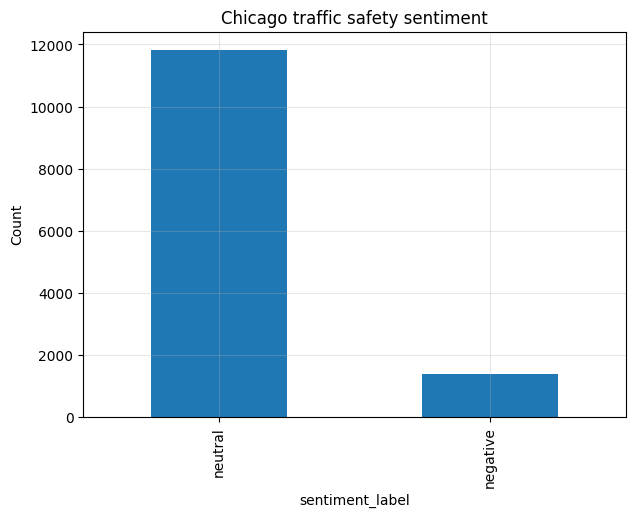

In [300]:
# SECTION 6 — SENTIMENT DISTRIBUTION

plt.figure(figsize=(7, 5))

traffic_df["sentiment_label"].value_counts().plot(
    kind="bar"
)

plt.title("Chicago traffic safety sentiment")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.show()

In [301]:
# SECTION 7 — MOST COMMON COMPLAINT THEMES

vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=30
)

X = vectorizer.fit_transform(traffic_df["text"])

counts = np.asarray(X.sum(axis=0)).ravel()
terms = vectorizer.get_feature_names_out()

freq = pd.DataFrame({
    "term": terms,
    "count": counts
}).sort_values("count", ascending=False)

freq.head(20)

,term,count
0,complaint,13099
7,light,11719
27,street light,11719
26,street,11719
8,light complaint,11119
23,signal complaint,1365
22,signal,1365
29,traffic signal,1365
28,traffic,1365
9,light day,423


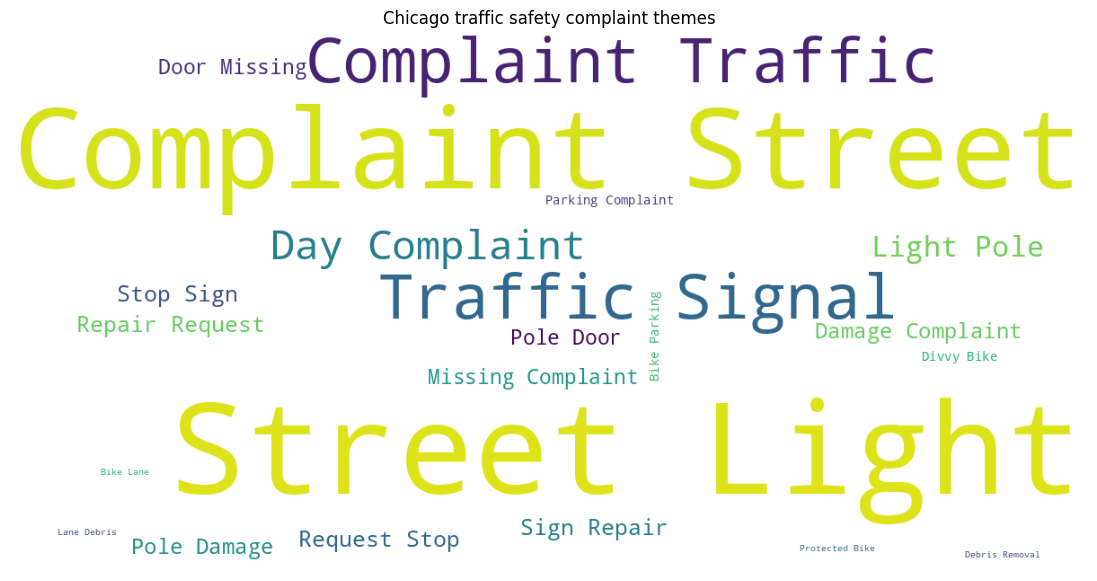

In [302]:
# SECTION 8 — WORD CLOUD

text_blob = " ".join(traffic_df["text"].astype(str).tolist())

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text_blob)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Chicago traffic safety complaint themes")
plt.show()

In [303]:
#SECTION 9 — SPATIAL HOTSPOT MAP
# Build Folium map

m = folium.Map(
    location=[41.84, -87.68],
    zoom_start=11,
    tiles="cartodbpositron"
)

sample_map = traffic_df.sample(
    min(1000, len(traffic_df)),
    random_state=42
)

for _, row in sample_map.iterrows():

    sent = row["sentiment"]

    if sent < -0.1:
        color = "red"
    elif sent > 0.1:
        color = "green"
    else:
        color = "blue"

    folium.CircleMarker(
        location=[row[lat_col], row[lon_col]],
        radius=4,
        color=color,
        fill=True,
        fill_opacity=0.6,
        popup=str(row["text"])[:250],
    ).add_to(m)

out_map = "outputs/chicago_traffic_sentiment_map.html"
Path("outputs").mkdir(exist_ok=True)

m.save(out_map)

print(f"Saved → {out_map}")
print()

Saved → outputs/chicago_traffic_sentiment_map.html



In [304]:
# SECTION 10 — COMPARE AGAINST CRASH HOTSPOTS
# Compare complaints vs model hotspots

hotspot_path = "outputs/cdot_priority_cells_lgbm.csv"

hotspots = pd.read_csv(hotspot_path)

print(hotspots.shape)

# Simple nearest-neighbor assignment

def nearest_hotspot(lat, lon, hs):
    d2 = (
        (hs["lat"] - lat) ** 2
        + (hs["lon"] - lon) ** 2
    )
    return d2.min()

traffic_df["dist_to_hotspot"] = traffic_df.apply(
    lambda r: nearest_hotspot(
        r[lat_col],
        r[lon_col],
        hotspots
    ),
    axis=1
)

threshold = 0.0025

traffic_df["near_hotspot"] = (
    traffic_df["dist_to_hotspot"] < threshold
)

summary = traffic_df.groupby("near_hotspot").agg(
    n_reports=("text", "count"),
    mean_sentiment=("sentiment", "mean")
)

print(summary)

(2430, 12)
              n_reports  mean_sentiment
near_hotspot                           
True              13201        0.012483


In [253]:
# SECTION 11 — INTERPRETATION

near = traffic_df[traffic_df["near_hotspot"]]
far = traffic_df[~traffic_df["near_hotspot"]]

print("=" * 60)
print("INTERPRETATION")
print("=" * 60)
print()

print(f"Complaints near model hotspots: {len(near):,}")
print(f"Complaints away from hotspots: {len(far):,}")
print()

print(f"Mean sentiment near hotspots: {near['sentiment'].mean():.3f}")
print(f"Mean sentiment away from hotspots: {far['sentiment'].mean():.3f}")
print()

if near['sentiment'].mean() < far['sentiment'].mean():
    print(
        "Residents near predicted crash hotspots report more negative "
        "traffic-safety sentiment, supporting the model's spatial risk signal."
    )
else:
    print(
        "Public sentiment does not strongly align with predicted crash hotspots. "
        "This suggests either under-reporting or latent risk not perceived by residents."
    )

out_csv = "outputs/chicago_traffic_sentiment.csv"
traffic_df.to_csv(out_csv, index=False)

print(f"Saved → {out_csv}")


INTERPRETATION

Complaints near model hotspots: 13,201
Complaints away from hotspots: 0

Mean sentiment near hotspots: 0.012
Mean sentiment away from hotspots: nan

Public sentiment does not strongly align with predicted crash hotspots. This suggests either under-reporting or latent risk not perceived by residents.
Saved → outputs/chicago_traffic_sentiment.csv


Public-reported traffic sentiment near predicted severe-crash hotspots was approximately neutral on average (mean sentiment ≈ 0.01), suggesting that areas identified as high-risk by the predictive model were not necessarily associated with strongly negative public reporting language. This finding may reflect underreporting (which capture from the equity audit Look at your top 10 list — 9 of the top 10 community areas by predicted risk per 1,000 residents are >90% minority. The exceptions are the Loop and Near South Side, which are downtown commercial districts where the high crash rate reflects high pedestrian and traffic volume rather than residential exposure. That's a real finding.)
Or it could be normalization of unsafe traffic conditions, or limitations of complaint-based civic reporting systems in capturing latent transportation risk.

All summary


In [310]:
!git clone https://github.com/utamiu1807/Final-Project-A-Spatiotemporal-Deep-Learning-Extension.git

fatal: destination path 'Final-Project-A-Spatiotemporal-Deep-Learning-Extension' already exists and is not an empty directory.


In [311]:
!zip -r outputs.zip outputs

updating: outputs/ (stored 0%)
updating: outputs/calibration_plot.png (deflated 11%)
updating: outputs/equity_audit_lgbm_vs_convlstm.csv (deflated 67%)
updating: outputs/clip_copresence.csv (deflated 43%)
updating: outputs/pai_curves.png (deflated 7%)
updating: outputs/community_areas_boundaries.geojson (deflated 67%)
updating: outputs/combined_summary.txt (deflated 49%)
updating: outputs/equity_audit_lgbm.csv (deflated 49%)
updating: outputs/cameras_per_cell.csv (deflated 57%)
updating: outputs/convlstm_predictions.csv (deflated 74%)
updating: outputs/cdot_priority_map_convlstm.html (deflated 92%)
updating: outputs/yolov8_mAP_bdd100k.csv (deflated 21%)
updating: outputs/cdot_priority_map_lgbm.html (deflated 92%)
updating: outputs/clip_overlays/ (stored 0%)
updating: outputs/clip_overlays/prev_02_overlay.mp4 (deflated 2%)
updating: outputs/clip_overlays/gap_01_overlay.mp4 (deflated 2%)
updating: outputs/clip_overlays/prev_01_overlay.mp4 (deflated 4%)
updating: outputs/chicago_traffic_s

In [312]:
from pathlib import Path

folders = [
    "vision-zero-chicago/notebooks",
    "vision-zero-chicago/data/raw",
    "vision-zero-chicago/data/processed",
    "vision-zero-chicago/data/cameras",
    "vision-zero-chicago/data/clips",
    "vision-zero-chicago/outputs/figures",
    "vision-zero-chicago/outputs/maps",
    "vision-zero-chicago/outputs/tables",
    "vision-zero-chicago/outputs/reports",
    "vision-zero-chicago/outputs/cv",
    "vision-zero-chicago/dashboard",
    "vision-zero-chicago/src/models",
    "vision-zero-chicago/src/features",
    "vision-zero-chicago/src/evaluation",
    "vision-zero-chicago/src/visualization",
    "vision-zero-chicago/src/utils",
    "vision-zero-chicago/docs",
]

for f in folders:
    Path(f).mkdir(parents=True, exist_ok=True)

print("✅ Project structure created")

✅ Project structure created


In [313]:
readme = """
# Vision Zero Chicago — Predictive Traffic Safety Analytics

This project builds a multimodal traffic-safety analytics pipeline for Chicago.

Components:
- LightGBM-Poisson crash forecasting
- ConvLSTM spatiotemporal forecasting
- Speed-camera mismatch analysis
- Computer vision pedestrian–vehicle exposure detection
- Public traffic-safety sentiment analysis
- Equity audit of predicted hotspots

Policy Partner:
Chicago Department of Transportation (CDOT)

Author:
[YOUR NAME]
Heinz College — Carnegie Mellon University
"""

with open("vision-zero-chicago/README.md", "w") as f:
    f.write(readme)

print("README created")

README created


In [314]:
gitignore = """
# Large files
*.ckpt
*.npz
*.mp4
*.zip

# Python
__pycache__/
.ipynb_checkpoints/

# Mac
.DS_Store

# Data
data/raw/*
"""

with open("vision-zero-chicago/.gitignore", "w") as f:
    f.write(gitignore)

print(".gitignore created")

.gitignore created


In [315]:
%cd vision-zero-chicago

!git init

/content/vision-zero-chicago
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/vision-zero-chicago/.git/


In [316]:
!git remote add origin https://github.com/utamiu1807/Final-Project-A-Spatiotemporal-Deep-Learning-Extension.git

In [318]:
!git add .
!git commit -m "Initial Vision Zero Chicago project"

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@df975f22b6f2.(none)')
